# ASyMOB cross-ablation analysis

Five ASyMOB evaluation runs, compared: figures, tables and paired statistical
tests for the results chapter.

| | training data | objective | on the γ path? |
|---|---|---|---|
| **A0** | none (base `Qwen2.5-Math-1.5B`) | — | no |
| **A1** | originals only | GRPO | no — different data |
| **A2** | originals + all variants | GRPO | **yes, γ = 1** |
| **A3 (γ=1.5)** | originals + all variants | GRPO + GRIP | **yes, γ = 1.5** |
| **A3** | originals + all variants | GRPO + GRIP | **yes, γ = 2** |

Two comparisons, not to be conflated:

* **A1 → A2** isolates *data augmentation* (same objective, different data).
* **A2 → A3** isolates *the objective* (same data, same hyperparameters, only the
  invariance penalty differs). **This is the thesis test.**
* **A2 → A3 (γ=1.5) → A3 (γ=2)** is the **γ path**: one estimator at three penalty
  strengths, which is what Figure 1 plots per family and Figure 12 summarises. In code
  the γ = 1.5 run is keyed `A3g1.5`.

**Figures show point estimates only.** Error bars and CI bands were removed to keep the
five-run figures readable — with three γ curves plus two reference curves, overlapping
bands obscured the very crossings Figure 1 exists to show. The uncertainty is not
dropped: every figure prints its 95% cluster-bootstrap intervals beneath it, the tables
carry them, and every claim of a difference rests on the paired tests, never on whether
whiskers overlapped.

### Where the data forced a departure from the analysis brief

Read this before the figures. Each point is verified in the cells below, not asserted.

1. **`Symbolic` has no `One`/`All` split.** The brief specifies Figure 1 as four
   panels — `Symbolic-One`, `Symbolic-All`, `Numeric-One`, `Numeric-All`. The runs
   contain `Symbolic-1 … Symbolic-5` with no One/All distinction. The families that
   actually carry an ordered intensity axis are `Numeric-One` (1–10),
   `Numeric-All` (0–10), `Symbolic` (1–5) and `Numeric-All-S` (2–3, stability
   replicates). Figure 1 uses the first three plus an **ordinal** `Equivalence`
   panel; the substitution is stated in the caption and the ordering assumption is
   made explicit.
2. **A0 ships no `items.jsonl`.** It is rebuilt in-notebook from A0's own
   `verified_generations.jsonl` using that run's own `aggregate_asymob.build_items`,
   then checked against A0's stored `summary.json`. Nothing is imputed.
3. **The `ablation` field in every manifest reads `"a0"`** — including A1, A2 and
   A3. It is mislabelled. Runs are identified by checkpoint path instead.
4. **G-Pass@8 exists only for originals.** Variants were generated with
   `n_samples = 1`, so no multi-sample reliability metric is defined for them.
   Figure 9 is originals-only and says so.
5. **`c_ans` is excluded**, per the brief: answer agreement is interpretable only
   where the perturbation preserves the reference answer, which holds for almost no
   ASyMOB family. It is present in `groups.jsonl` and deliberately unused.
6. **A3's generation health is a first-order threat to its numbers**, not a
   footnote. This is quantified in Figure 10 and carried into the written analysis. With
   γ = 1.5 now available it is also clear that the collapse is **not** smooth in γ: it is
   mild at γ = 1.5 and abrupt at γ = 2.
7. **The γ = 1.5 run** (`a3_asymob_g15_20260918`, checkpoint `a3_grpo_grip_g1.5`,
   evaluated 2026-09-20) was checked like the others: same `metrics.py` and
   `aggregate_asymob.py`, same data file, seed and sampling settings, the same 100 seeds
   and 32 arms, no NaNs, and a `summary.json` that reproduces from its own raw files.

In [1]:
import os, sys, json, math, glob, textwrap, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# The repository root is found by walking up from the working directory, so the
# notebook can be run from anywhere in the repo without absolute paths.
def _repo_root():
    here = Path(os.getcwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "ablations").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise RuntimeError("repository root not found: expected a parent directory "
                       "containing both ablations/ and README.md")

REPO   = _repo_root()
BASE   = str(REPO / "ablations" / "eval" / "asymob")
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

RUNS = {
    "A0": f"{BASE}/a0_asymob_1.5B_20260904",   # untrained Qwen2.5-Math-1.5B
    "A1": f"{BASE}/a1_asymob_20260915",        # GRPO, originals only
    "A2": f"{BASE}/a2_asymob_20260915",        # GRPO, originals + variants   (gamma = 1)
    "A3g1.5": f"{BASE}/a3_asymob_gamma1.5_20260918",  # GRPO + GRIP, gamma = 1.5
    "A3": f"{BASE}/a3_asymob_gamma2_20260915",        # GRPO + GRIP, gamma = 2
}
ORDER = ["A0", "A1", "A2", "A3g1.5", "A3"]     # gamma-path runs in increasing gamma

LABEL = {"A0": "A0  base (untrained)",
         "A1": "A1  GRPO, originals",
         "A2": "A2  GRPO, augmented  ($\\gamma$=1)",
         "A3g1.5": "A3  GRPO+GRIP  ($\\gamma$=1.5)",
         "A3": "A3  GRPO+GRIP  ($\\gamma$=2)"}
SHORT = {"A0": "A0", "A1": "A1", "A2": "A2 ($\\gamma$=1)",
         "A3g1.5": "A3 ($\\gamma$=1.5)", "A3": "A3 ($\\gamma$=2)"}

# A0 grey; A2 and A3 share a hue because they are one estimator at two gammas,
# light -> dark with increasing gamma. A3 is the strongest colour on every figure.
COLOR = {"A0": "#9E9E9E", "A1": "#66A182", "A2": "#6BAED6", "A3g1.5": "#2F74B5", "A3": "#08306B"}

# Grouped-bar geometry scales with the number of runs.
BW = 0.8 / len(ORDER)
def boff(i):
    return (i - (len(ORDER) - 1) / 2) * BW

B_BOOT, SEED = 10_000, 0

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.width", 200, "display.max_columns", 60)

def savefig(fig, name):
    for ext in ("pdf", "png"):
        p = os.path.join(FIGDIR, f"{name}.{ext}")
        fig.savefig(p, dpi=300)
    print(f"saved  {FIGDIR}/{name}.{{pdf,png}}")

RESULTS = {}   # everything that lands in a table, dumped to results_summary.json at the end
print("figures ->", FIGDIR)

figures -> /home/amz/projects/GRIP/ablations/eval/asymob/figures


---
## 1. Loading

One loader, no hardcoded depth: each run is found by globbing `**/summary.json`.
A missing run raises with the attempted path — an ablation is never silently skipped.

In [2]:
def _jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))   # json.loads accepts bare NaN
    return rows


def _locate(run_dir, filename, required=True):
    '''Glob for a file anywhere under run_dir. Fail loudly with the attempted path.'''
    pattern = os.path.join(run_dir, "**", filename)
    hits = sorted(glob.glob(pattern, recursive=True))
    if not hits:
        if required:
            raise FileNotFoundError(
                f"required file not found\n  looked for : {pattern}\n"
                f"  run dir    : {run_dir} (exists={os.path.isdir(run_dir)})")
        return None
    if len(hits) > 1:
        print(f"  ! {len(hits)} matches for {filename}, using {hits[0]}")
    return hits[0]


def _rebuild_items(eval_dir):
    '''Rebuild items.jsonl from verified_generations.jsonl using the RUN'S OWN
    aggregation code, so the reconstruction cannot drift from how the shipped
    runs were built.'''
    vg = os.path.join(eval_dir, "verified_generations.jsonl")
    if not os.path.exists(vg):
        raise FileNotFoundError(f"cannot rebuild items: missing {vg}")
    sys.path.insert(0, eval_dir)
    try:
        for m in ("aggregate_asymob", "metrics"):
            sys.modules.pop(m, None)
        import aggregate_asymob as agg
        items = agg.build_items(agg.load_jsonl(vg), binarise="majority")
    finally:
        sys.path.remove(eval_dir)
    return items


def load_runs(runs=RUNS):
    data = {}
    for key, run_dir in runs.items():
        if not os.path.isdir(run_dir):
            raise FileNotFoundError(f"[{key}] run directory missing: {run_dir}")

        s_path = _locate(run_dir, "summary.json")
        g_path = _locate(run_dir, "groups.jsonl")
        eval_dir = os.path.dirname(s_path)

        summary = json.load(open(s_path))
        groups  = _jsonl(g_path)

        i_path = _locate(run_dir, "items.jsonl", required=False)
        if i_path:
            items, src = _jsonl(i_path), "items.jsonl"
        else:
            print(f"[{key}] no items.jsonl under {run_dir} "
                  f"-- rebuilding from verified_generations.jsonl")
            items, src = _rebuild_items(eval_dir), "rebuilt from verified_generations.jsonl"

        m_path = _locate(run_dir, "manifest.json", required=False)
        manifest = json.load(open(m_path)) if m_path else {}

        data[key] = {"summary": summary, "groups": pd.DataFrame(groups),
                     "items": pd.DataFrame(items), "manifest": manifest,
                     "eval_dir": eval_dir, "items_source": src,
                     "groups_raw": groups}
        print(f"[{key}] {len(groups):>4} groups   {len(items):>6} items   ({src})")
    return data


data = load_runs()

[A0] no items.jsonl under /home/amz/projects/GRIP/ablations/eval/asymob/a0_asymob_1.5B_20260904 -- rebuilding from verified_generations.jsonl


[A0]  100 groups    35368 items   (rebuilt from verified_generations.jsonl)


[A1]  100 groups    35368 items   (items.jsonl)


[A2]  100 groups    35368 items   (items.jsonl)


[A3g1.5]  100 groups    35368 items   (items.jsonl)


[A3]  100 groups    35368 items   (items.jsonl)


In [3]:
# Run identity. The `ablation` field reads "a0" in every manifest, which is a
# mislabel, so identity is taken from the checkpoint path instead.
rows = []
for k in ORDER:
    m = data[k]["manifest"]
    rows.append({
        "run": k,
        "run_id": m.get("run_id", "?"),
        "manifest.ablation": m.get("ablation", "?"),
        "model / checkpoint": os.path.basename(
            os.path.dirname(m.get("model", {}).get("name", "?").rstrip("/"))) or
            m.get("model", {}).get("name", "?"),
        "n_samples": m.get("generation", {}).get("n_samples", "?"),
        "max_new_tokens": m.get("generation", {}).get("max_new_tokens", "?"),
        "seed": m.get("global_seed", "?"),
    })
ident = pd.DataFrame(rows).set_index("run")
print(ident.to_string())

bad = ident["manifest.ablation"].nunique() == 1 and len(ident) > 1
print("\n! manifest.ablation is identical across all runs -- MISLABELLED. "
      "Runs identified by checkpoint path instead." if bad else "\nmanifest.ablation looks distinct.")

same_gen = ident[["n_samples", "max_new_tokens", "seed"]].drop_duplicates()
print(f"generation settings identical across runs: {len(same_gen) == 1}")

                         run_id manifest.ablation    model / checkpoint                                      n_samples  max_new_tokens  seed
run                                                                                                                                         
A0      a0_asymob_20260904_1.5B                a0                  Qwen  from preprocessing (8 originals / 1 variants)            3072    42
A1           a1_asymob_20260915                a0  a1_grpo_originals_v3  from preprocessing (8 originals / 1 variants)            3072    42
A2           a2_asymob_20260915                a0  a2_grpo_augmented_v3  from preprocessing (8 originals / 1 variants)            3072    42
A3g1.5   a3_asymob_g15_20260918                a0     a3_grpo_grip_g1.5  from preprocessing (8 originals / 1 variants)            3072    42
A3           a3_asymob_20260915                a0       a3_grpo_grip_g2  from preprocessing (8 originals / 1 variants)            3072    42

! manifest.a

---
## 2. Taxonomy — what strength axis actually exists

The brief's snippet assumes `meta.family` / `meta.intensity` columns on
`groups.jsonl`. They are not there: `groups.jsonl` carries `family_by_arm`, and the
family/intensity taxonomy lives in `items.jsonl`. Printed below from the real schema,
before anything is plotted.

In [4]:
def items_long(data):
    frames = []
    for k in ORDER:
        df = data[k]["items"].copy()
        df["run"] = k
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["intensity"] = pd.to_numeric(out["intensity"], errors="coerce")
    return out

IT = items_long(data)

for k in ORDER:
    d = IT[IT.run == k]
    print(f"{k} families :", sorted(d.family.dropna().unique()))
    print(f"{k} intensity:", sorted(d.intensity.dropna().unique()))
print()

piv = (IT[~IT.is_original]
       .groupby(["family", "intensity"], dropna=False).size()
       .rename("n_items_all_runs").reset_index())
piv["n_per_run"] = piv["n_items_all_runs"] // len(ORDER)
print(f"n per (family, intensity)   [pooled over the {len(ORDER)} runs, and per run]")
print(piv.to_string(index=False))

print("\narms present in groups.jsonl:", len(data['A0']['summary']['by_arm']))
print(sorted(data["A0"]["summary"]["by_arm"]))

A0 families : ['Equivalence-All-Easy', 'Equivalence-All-Hard', 'Equivalence-One-Easy', 'Equivalence-One-Hard', 'Numeric-All', 'Numeric-All-S', 'Numeric-One', 'Original', 'Symbolic']
A0 intensity: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
A1 families : ['Equivalence-All-Easy', 'Equivalence-All-Hard', 'Equivalence-One-Easy', 'Equivalence-One-Hard', 'Numeric-All', 'Numeric-All-S', 'Numeric-One', 'Original', 'Symbolic']
A1 intensity: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
A2 families : ['Equivalence-All-Easy', 'Equivalence-All-Hard', 'Equivalence-One-Easy', 'Equivalence-One-Hard', 'Numeric-All', 'Numeric-All-S', 'Numeric-One', 'Original', 'Symbolic']
A2 intensity: [np.float64(0.0), np.float64(1.0),

In [5]:
# Which families carry an ordered intensity axis, and which do not.
fam_int = (IT[~IT.is_original].groupby("family")["intensity"]
           .agg(lambda s: sorted(s.dropna().unique())))
ORDERED_FAMS, FLAT_FAMS = [], []
for fam, levels in fam_int.items():
    (ORDERED_FAMS if len(levels) >= 2 else FLAT_FAMS).append(fam)

print("ordered intensity axis :", ORDERED_FAMS)
print("no intensity axis      :", FLAT_FAMS)

# Equivalence has no numeric intensity. Its four arms do carry a defensible ORDINAL
# ordering: One before All (number of substitutions), Easy before Hard. This is a
# partial order promoted to a total one, and is stated as an assumption.
EQUIV_ORDINAL = ["Equivalence-One-Easy", "Equivalence-One-Hard",
                 "Equivalence-All-Easy", "Equivalence-All-Hard"]
assert set(EQUIV_ORDINAL) <= set(FLAT_FAMS), set(FLAT_FAMS)
print("\nEquivalence ordinal axis (ASSUMED ordering, stated in the Fig 1 caption):")
for i, f in enumerate(EQUIV_ORDINAL, 1):
    print(f"   {i}. {f}")

# Family display order, by distance from the training perturbations (Fig 7 order):
#   Numeric    = the kernel perturbation seen in training      (in-family)
#   Symbolic   = surface renaming, adjacent                     (adjacent)
#   Equivalence= nothing in training resembles it               (out-of-family)
FAMILY_ORDER = ["Numeric-One", "Numeric-All", "Numeric-All-S", "Symbolic"] + EQUIV_ORDINAL
FAMILY_ORDER = [f for f in FAMILY_ORDER if f in set(IT.family.dropna())]
print("\nfamily display order:", FAMILY_ORDER)

ordered intensity axis : ['Numeric-All', 'Numeric-All-S', 'Numeric-One', 'Symbolic']
no intensity axis      : ['Equivalence-All-Easy', 'Equivalence-All-Hard', 'Equivalence-One-Easy', 'Equivalence-One-Hard']

Equivalence ordinal axis (ASSUMED ordering, stated in the Fig 1 caption):
   1. Equivalence-One-Easy
   2. Equivalence-One-Hard
   3. Equivalence-All-Easy
   4. Equivalence-All-Hard



family display order: ['Numeric-One', 'Numeric-All', 'Numeric-All-S', 'Symbolic', 'Equivalence-One-Easy', 'Equivalence-One-Hard', 'Equivalence-All-Easy', 'Equivalence-All-Hard']


---
## 3. Data validation

`gap_mean` returned NaN in an earlier ASyMOB aggregation. That was fixed, so this is
a regression check. If everything is zero we proceed on plain means; otherwise every
downstream statistic switches to `nanmean`/`nanvar` with effective *n* reported.

In [6]:
val = []
for k in ORDER:
    g = data[k]["groups"]
    row = {"run": k, "n_groups": len(g),
           "n_variants_scored==0": int((g["n_variants_scored"] == 0).sum())}
    for f in ["gap_mean", "within_var", "c_corr", "acc_original"]:
        col = {"gap_mean": "gap", "acc_original": "acc_orig"}.get(f, f)
        row[f"NaN {f}"] = int(g[col].isna().sum()) if col in g else "n/a"
    val.append(row)
VAL = pd.DataFrame(val).set_index("run")
print(VAL.to_string())

CLEAN = bool((VAL.drop(columns=["n_groups"]).to_numpy() == 0).all())
print("\n" + ("All validation counters are zero: no groups dropped, no NaN in gap, "
              "within_var, c_corr or acc_original. Proceeding on plain means."
              if CLEAN else
              "NON-ZERO counters above: nan-aware aggregation is used throughout and "
              "effective n is reported with every statistic."))

RESULTS["validation"] = VAL.reset_index().to_dict("records")
RESULTS["validation_clean"] = CLEAN

        n_groups  n_variants_scored==0  NaN gap_mean  NaN within_var  NaN c_corr  NaN acc_original
run                                                                                               
A0           100                     0             0               0           0                 0
A1           100                     0             0               0           0                 0
A2           100                     0             0               0           0                 0
A3g1.5       100                     0             0               0           0                 0
A3           100                     0             0               0           0                 0

All validation counters are zero: no groups dropped, no NaN in gap, within_var, c_corr or acc_original. Proceeding on plain means.


In [7]:
# A0's items were reconstructed. Verify the reconstruction against A0's own
# stored summary.json: health, degradation curve and mG-Pass must match exactly.
def verify_rebuild(key):
    d = data[key]
    if "rebuilt" not in d["items_source"]:
        print(f"[{key}] items.jsonl shipped with the run -- nothing to verify")
        return True
    it, s = d["items"], d["summary"]
    ok = True

    reb_health = {"truncation_rate": float(it.truncation_rate.mean()),
                  "format_ok_rate": float(it.format_ok_rate.mean()),
                  "extract_fail_rate": float(it.extract_fail_rate.mean())}
    for kk, v in reb_health.items():
        match = math.isclose(v, s["health"][kk], rel_tol=0, abs_tol=1e-12)
        ok &= match
        print(f"[{key}] health.{kk:<18} rebuilt={v:.12f} stored={s['health'][kk]:.12f}  "
              f"{'OK' if match else 'MISMATCH'}")

    sub = it[(~it.is_original) & it.intensity.notna() & it.avg_n.notna()]
    reb = (sub.groupby(["family", "intensity"])["avg_n"]
              .agg(acc="mean", n_items="size").reset_index()
              .sort_values(["family", "intensity"]).reset_index(drop=True))
    sto = (pd.DataFrame(s["degradation_curve"])
             .sort_values(["family", "intensity"]).reset_index(drop=True))
    same = (len(reb) == len(sto)
            and (reb.family.values == sto.family.values).all()
            and np.allclose(reb.intensity.values.astype(float), sto.intensity.values.astype(float))
            and np.allclose(reb.acc.values, sto.acc.values, atol=1e-12)
            and (reb.n_items.values == sto.n_items.values).all())
    ok &= same
    print(f"[{key}] degradation_curve  {len(reb)} rows  {'OK' if same else 'MISMATCH'}")

    mg = float(it.loc[it.is_original, "mg_pass_at_8"].mean())
    same_mg = math.isclose(mg, s["mg_pass_at_8_orig_mean"], abs_tol=1e-12)
    ok &= same_mg
    print(f"[{key}] mG-Pass@8(orig)    rebuilt={mg:.12f} stored={s['mg_pass_at_8_orig_mean']:.12f}  "
          f"{'OK' if same_mg else 'MISMATCH'}")
    return ok

rebuild_ok = all(verify_rebuild(k) for k in ORDER)
print("\nreconstruction verified against stored summaries:", rebuild_ok)
assert rebuild_ok, "A0 item reconstruction does not reproduce its own summary -- stop."
RESULTS["a0_items_rebuild_verified"] = rebuild_ok

[A0] health.truncation_rate    rebuilt=0.030684517078 stored=0.030684517078  OK
[A0] health.format_ok_rate     rebuilt=0.917344068084 stored=0.917344068084  OK
[A0] health.extract_fail_rate  rebuilt=0.084698738973 stored=0.084698738973  OK
[A0] degradation_curve  28 rows  OK
[A0] mG-Pass@8(orig)    rebuilt=0.152500000000 stored=0.152500000000  OK
[A1] items.jsonl shipped with the run -- nothing to verify
[A2] items.jsonl shipped with the run -- nothing to verify
[A3g1.5] items.jsonl shipped with the run -- nothing to verify
[A3] items.jsonl shipped with the run -- nothing to verify

reconstruction verified against stored summaries: True


In [8]:
# Group alignment: every paired test below runs on the intersection.
sets = {k: set(data[k]["groups"].group_id) for k in ORDER}
SHARED = sorted(set.intersection(*sets.values()))
print(f"group_ids shared by all {len(ORDER)} runs: {len(SHARED)}")
for k in ORDER:
    extra = len(sets[k] - set(SHARED))
    print(f"  {k}: {len(sets[k]):>4} groups, {extra:>3} dropped as unshared")
RESULTS["n_shared_groups"] = len(SHARED)
RESULTS["n_dropped_unshared"] = {k: len(sets[k] - set(SHARED)) for k in ORDER}

group_ids shared by all 5 runs: 100
  A0:  100 groups,   0 dropped as unshared
  A1:  100 groups,   0 dropped as unshared
  A2:  100 groups,   0 dropped as unshared
  A3g1.5:  100 groups,   0 dropped as unshared
  A3:  100 groups,   0 dropped as unshared


---
## 4. Bootstrap machinery

Every interval in this notebook resamples **seeds** (`group_id`), never items,
with `B = 10,000` and `seed = 0`.

Seed-level resampling is required because the variants of one seed are rewrites of
the same problem. Item-level resampling would treat correlated observations as
independent and yield intervals roughly $\sqrt{|V_i|}$ too narrow — with a median of
~298 variants per seed, that is an understatement of roughly 17×.

Two estimators are needed:

* `cluster_bootstrap` — for statistics that are a **mean of per-group values**
  (gap, accuracy, within-seed variance, G-Pass).
* `ratio_cluster_bootstrap` — for statistics that are a **ratio of sums**
  (RSR $=\sum_i e_i h_i / \sum_i e_i$, recovery rate). Resampling a per-group ratio
  would weight a seed with two scored variants like one with four hundred.

`paired_*` variants draw **one** group index per replicate and apply it to both
runs, so the pairing survives the resample.

In [9]:
def _draw(n, B=B_BOOT, seed=SEED):
    return np.random.default_rng(seed).integers(0, n, size=(B, n))


def cluster_bootstrap(values_by_group, B=B_BOOT, seed=SEED):
    '''Mean of a per-group statistic, resampling groups with replacement.
    NaN groups are dropped before resampling; the returned n is the effective n.'''
    keys = list(values_by_group)
    v = np.asarray([values_by_group[k] for k in keys], dtype=float)
    n_input = len(v)
    v = v[~np.isnan(v)]
    n = len(v)
    if n == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": 0, "n_input": n_input}
    means = v[_draw(n, B, seed)].mean(axis=1)
    return {"mean": float(v.mean()), "lo": float(np.percentile(means, 2.5)),
            "hi": float(np.percentile(means, 97.5)), "n": n, "n_input": n_input}


def paired_cluster_bootstrap(stat_a, stat_b, group_ids=None, B=B_BOOT, seed=SEED):
    '''Mean paired difference (a - b) over the groups both runs share.
    Returns mean difference, 95% interval, and whether that interval excludes 0.'''
    keys = sorted(set(stat_a) & set(stat_b)) if group_ids is None \
           else [k for k in group_ids if k in stat_a and k in stat_b]
    diffs = {k: stat_a[k] - stat_b[k] for k in keys}
    out = cluster_bootstrap(diffs, B=B, seed=seed)
    out["significant"] = bool(not np.isnan(out["lo"]) and (out["lo"] > 0 or out["hi"] < 0))
    return out


def ratio_cluster_bootstrap(num_by_group, den_by_group, B=B_BOOT, seed=SEED):
    '''Ratio-of-sums statistic (RSR, recovery), resampling groups.'''
    keys = sorted(set(num_by_group) & set(den_by_group))
    num = np.asarray([num_by_group[k] for k in keys], dtype=float)
    den = np.asarray([den_by_group[k] for k in keys], dtype=float)
    ok = ~(np.isnan(num) | np.isnan(den))
    num, den = num[ok], den[ok]
    n = len(num)
    if n == 0 or den.sum() == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": n}
    idx = _draw(n, B, seed)
    ns, ds = num[idx].sum(axis=1), den[idx].sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        reps = np.where(ds > 0, ns / ds, np.nan)
    return {"mean": float(num.sum() / den.sum()),
            "lo": float(np.nanpercentile(reps, 2.5)),
            "hi": float(np.nanpercentile(reps, 97.5)), "n": n}


def paired_ratio_cluster_bootstrap(na, da, nb, db, B=B_BOOT, seed=SEED):
    '''Paired difference of two ratio-of-sums statistics, one group draw for both.'''
    keys = sorted(set(na) & set(da) & set(nb) & set(db))
    A = np.asarray([[na[k], da[k], nb[k], db[k]] for k in keys], dtype=float)
    A = A[~np.isnan(A).any(axis=1)]
    n = len(A)
    if n == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": 0, "significant": False}
    idx = _draw(n, B, seed)
    S = A[idx].sum(axis=1)                       # (B, 4)
    with np.errstate(invalid="ignore", divide="ignore"):
        reps = np.where((S[:, 1] > 0) & (S[:, 3] > 0), S[:, 0] / S[:, 1] - S[:, 2] / S[:, 3], np.nan)
    tot = A.sum(axis=0)
    point = (tot[0] / tot[1] - tot[2] / tot[3]) if tot[1] > 0 and tot[3] > 0 else np.nan
    lo, hi = float(np.nanpercentile(reps, 2.5)), float(np.nanpercentile(reps, 97.5))
    return {"mean": float(point), "lo": lo, "hi": hi, "n": n,
            "significant": bool(lo > 0 or hi < 0)}


def fmt_ci(d, p=3):
    if d is None or (isinstance(d.get("mean"), float) and np.isnan(d["mean"])):
        return "--"
    return f"{d['mean']:.{p}f} [{d['lo']:.{p}f}, {d['hi']:.{p}f}]"


# sanity: the helper must reproduce the CI the runs shipped in summary.json
chk = cluster_bootstrap(dict(zip(data["A0"]["groups"].group_id, data["A0"]["groups"].gap)))
print("gap A0  recomputed:", fmt_ci(chk), f"(n={chk['n']})")
print("gap A0  in summary:", f"{data['A0']['summary']['gap_mean']:.3f} "
      f"[{data['A0']['summary']['gap_ci'][0]:.3f}, {data['A0']['summary']['gap_ci'][1]:.3f}] "
      f"(n={data['A0']['summary']['gap_n']})")

gap A0  recomputed: 0.145 [0.091, 0.203] (n=100)
gap A0  in summary: 0.145 [0.091, 0.203] (n=100)


In [10]:
# ── shared long-format frames used by every figure ───────────────────────────

def arms_long(data):
    '''One row per (run, group, arm): accuracy, gap, binarised outcome, family.'''
    rows = []
    for k in ORDER:
        for g in data[k]["groups_raw"]:
            for arm, acc in g["acc_by_arm"].items():
                rows.append({"run": k, "group_id": g["group_id"], "arm": arm,
                             "family": g["family_by_arm"].get(arm, ""),
                             "acc": acc, "gap": g["gap_by_arm"].get(arm, np.nan),
                             "h": g["h_by_arm"].get(arm, np.nan), "e_i": g["e_i"]})
    df = pd.DataFrame(rows)
    return df[df.group_id.isin(SHARED)].copy()

AR = arms_long(data)
IT = IT[IT.group_id.isin(SHARED)].copy()

# per-group originals accuracy, the capability axis
ACC_ORIG = {k: dict(zip(data[k]["groups"].group_id, data[k]["groups"].acc_orig)) for k in ORDER}
E_I      = {k: dict(zip(data[k]["groups"].group_id, data[k]["groups"].e_i)) for k in ORDER}
GAP_ALL  = {k: dict(zip(data[k]["groups"].group_id, data[k]["groups"].gap)) for k in ORDER}
WVAR     = {k: dict(zip(data[k]["groups"].group_id, data[k]["groups"].within_var)) for k in ORDER}
CCORR    = {k: dict(zip(data[k]["groups"].group_id, data[k]["groups"].c_corr)) for k in ORDER}

# per-group mean accuracy over all variant arms
ACC_VARS = {k: AR[AR.run == k].groupby("group_id")["acc"].mean().to_dict() for k in ORDER}

print("arms_long:", AR.shape, " items:", IT.shape)
print("arms per group:", AR.groupby(['run','group_id']).size().min(), "-",
      AR.groupby(['run','group_id']).size().max())

arms_long: (15245, 8)  items: (176840, 30)
arms per group: 29 - 32


In [11]:
# per-group accuracy in each (family, intensity) cell - the Figure 1 substrate
def cell_accuracy(IT):
    sub = IT[(~IT.is_original)].copy()
    ordered = sub[sub.intensity.notna()].copy()
    ordered["cell"] = ordered["intensity"]
    # Equivalence: ordinal position on the assumed One-Easy < One-Hard < All-Easy < All-Hard axis
    eq = sub[sub.family.isin(EQUIV_ORDINAL)].copy()
    eq["cell"] = eq.family.map({f: i + 1 for i, f in enumerate(EQUIV_ORDINAL)}).astype(float)
    eq["family"] = "Equivalence"
    both = pd.concat([ordered, eq], ignore_index=True)
    return (both.groupby(["run", "family", "cell", "group_id"])["avg_n"]
                .mean().rename("acc").reset_index())

CELL = cell_accuracy(IT)
CELL_N = (IT[~IT.is_original].assign(
              cell=lambda d: d.intensity,
              fam=lambda d: d.family)
          .dropna(subset=["cell"])
          .groupby(["run", "fam", "cell"]).size())
print(CELL.groupby(["family"])["cell"].agg(lambda s: sorted(s.unique())))

family
Equivalence                                   [1.0, 2.0, 3.0, 4.0]
Numeric-All      [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...
Numeric-All-S                                           [2.0, 3.0]
Numeric-One      [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...
Symbolic                                 [1.0, 2.0, 3.0, 4.0, 5.0]
Name: cell, dtype: object


---
## Figure 1 — the γ-path trade-off curves

**What it shows.** Accuracy against perturbation strength, one curve per γ, in the
structure of Rothenhäusler et al. Fig. 2.2: a regularisation path, where every curve
on the path is *the same estimator at a different γ*.

* **A2 = γ 1** — plain GRPO on augmented data, the unpenalised endpoint.
* **γ = 1.5** — GRIP, intermediate penalty.
* **A3 = γ 2** — GRIP, full penalty.

**y-axis is accuracy** (not 1 − accuracy): higher is better, everywhere in this
notebook. Curves are point estimates; the per-level intervals are available from
`gamma_curve()` and the crossing table beneath quantifies what the eye would read off
bands.

**A0 and A1 are context, not path members.** A0 is untrained and A1 saw different
data, so neither is the same estimator at a different γ. They are drawn thin, grey
and unmarked under a separate legend heading, purely to show where the model starts
and what augmentation alone achieves.

**What it is testing.** Anchor regression predicts that a larger γ trades accuracy
at low perturbation strength for stability at high strength — **the curves should
cross**. A flatter, lower-starting A3 that ends *above* A2 is the signature of a real
trade-off. A3 below A2 at every strength is levelling down, not a trade-off.

**Axis substitution (see the header).** `Symbolic` has no One/All split in this data,
so the brief's four panels are not buildable as written. The panels are the three
families that carry a genuine ordered intensity axis — `Numeric-One` (1–10),
`Numeric-All` (0–10), `Symbolic` (1–5) — plus `Equivalence` on an **ordinal** axis
(One-Easy → One-Hard → All-Easy → All-Hard), which is an assumed ordering, not a
measured intensity, and is marked as such on the panel. `Numeric-All-S` (the
stability replicates, intensities 2–3 only) is shown separately as Figure 1b.

Each panel is annotated with its per-level n.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig01_gamma_path.{pdf,png}


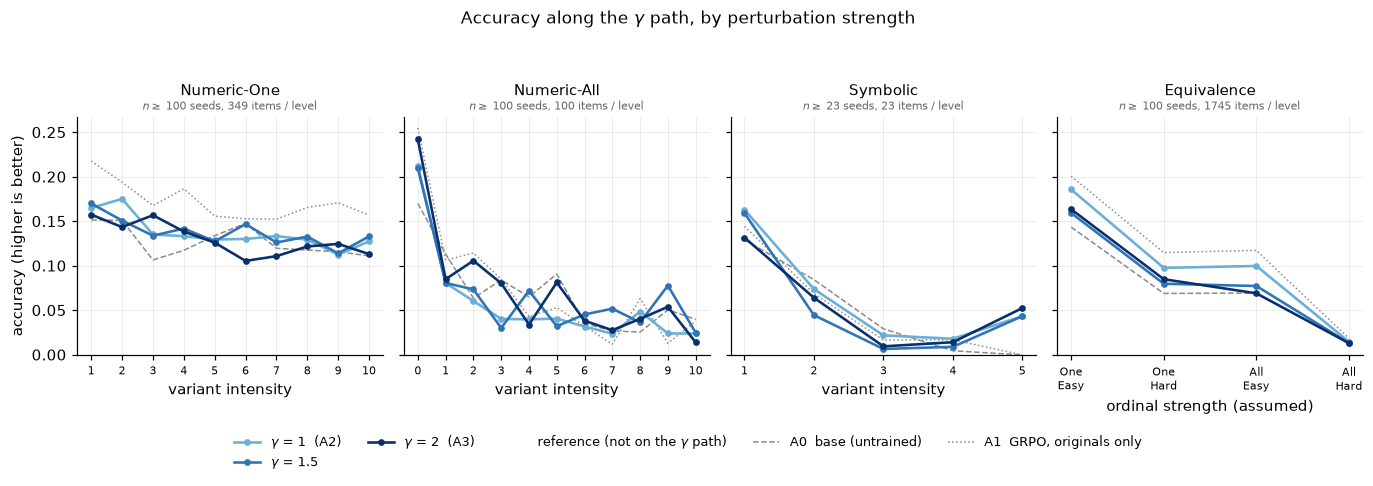


Figure 1 -- n per level (minimum across runs):
panel  Equivalence  Numeric-All  Numeric-One  Symbolic
level                                                 
0.0            NaN        100.0          NaN       NaN
1.0          100.0        100.0        100.0     100.0
2.0          100.0        100.0        100.0     100.0
3.0          100.0        100.0        100.0      82.0
4.0          100.0        100.0        100.0      44.0
5.0            NaN        100.0        100.0      23.0
6.0            NaN        100.0        100.0       NaN
7.0            NaN        100.0        100.0       NaN
8.0            NaN        100.0        100.0       NaN
9.0            NaN        100.0        100.0       NaN
10.0           NaN        100.0        100.0       NaN


In [12]:
PANELS = [("Numeric-One",  "variant intensity",              False),
          ("Numeric-All",  "variant intensity",              False),
          ("Symbolic",     "variant intensity",              False),
          ("Equivalence",  "ordinal strength (assumed)",     True)]

GAMMA_CURVES = {"$\\gamma$ = 1  (A2)": "A2",
                "$\\gamma$ = 1.5": "A3g1.5",
                "$\\gamma$ = 2  (A3)": "A3"}      # a further gamma is one more entry here
REFERENCE_RUNS = {"A0": ("--", "A0  base (untrained)"),
                  "A1": (":",  "A1  GRPO, originals only")}


def gamma_curve(run, family, B=B_BOOT):
    '''Bootstrapped accuracy per strength level for one run and family.'''
    sub = CELL[(CELL.run == run) & (CELL.family == family)]
    out = []
    for cell, grp in sub.groupby("cell"):
        bs = cluster_bootstrap(dict(zip(grp.group_id, grp.acc)), B=B)
        out.append({"cell": cell, **bs})
    return pd.DataFrame(out).sort_values("cell")


def plot_gamma_path(panels=PANELS, curves=GAMMA_CURVES, reference=REFERENCE_RUNS,
                    figname="fig01_gamma_path", B=B_BOOT):
    '''Figure 1. `curves` is a {label: run_key} dict -- adding a gamma=1.5 run is a
    one-line edit to GAMMA_CURVES, nothing else changes.'''
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(3.15 * n, 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    ntab, curve_cache = [], {}

    for ax, (fam, xlabel, ordinal) in zip(axes, panels):
        for run, (ls, _) in reference.items():
            c = gamma_curve(run, fam, B)
            if c.empty:
                continue
            ax.plot(c.cell, c["mean"], ls=ls, lw=1.0, color="#8A8A8A", zorder=1)

        for lab, run in curves.items():
            c = gamma_curve(run, fam, B)
            curve_cache[(fam, run)] = c
            if c.empty:
                continue
            ax.plot(c.cell, c["mean"], "-o", ms=3.4, lw=1.7, color=COLOR[run], zorder=3)

        ref = gamma_curve(list(curves.values())[0], fam, B)
        for _, r in ref.iterrows():
            nper = int(CELL[(CELL.family == fam) & (CELL.cell == r.cell)]
                       .groupby("run").size().min())
            ntab.append({"panel": fam, "level": r.cell, "n_groups_per_run": nper})

        ax.set_xlabel(xlabel)
        nn = int(CELL[CELL.family == fam].groupby(["run", "cell"]).size().min())
        n_it = int(IT[(IT.run == "A0") &
                      (IT.family.isin(EQUIV_ORDINAL if fam == "Equivalence" else [fam]))]
                   .groupby("family" if fam == "Equivalence" else "intensity").size().min())
        ax.set_title(fam, fontsize=10, pad=14)
        ax.text(0.5, 1.015, f"$n \\geq$ {nn} seeds, {n_it} items / level",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=7, color="#666")
        if ordinal:
            ax.set_xticks(range(1, len(EQUIV_ORDINAL) + 1))
            ax.set_xticklabels(["One\nEasy", "One\nHard", "All\nEasy", "All\nHard"], fontsize=7.5)
        else:
            ax.set_xticks(sorted(ref.cell.astype(int)))
            ax.tick_params(axis="x", labelsize=7.5)

    axes[0].set_ylabel("accuracy (higher is better)")
    axes[0].set_ylim(bottom=0)

    handles = [Line2D([], [], color=COLOR[r], marker="o", ms=3.4, lw=1.7, label=l)
               for l, r in curves.items()]
    handles += [Line2D([], [], color="none", label="reference (not on the $\\gamma$ path)")]
    handles += [Line2D([], [], color="#8A8A8A", ls=ls, lw=1.0, label=lab)
                for r, (ls, lab) in reference.items()]
    fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.13))
    fig.suptitle("Accuracy along the $\\gamma$ path, by perturbation strength", y=1.06)
    fig.tight_layout()
    savefig(fig, figname)
    plt.show()
    return pd.DataFrame(ntab), curve_cache


N1, CURVES1 = plot_gamma_path()
print("\nFigure 1 -- n per level (minimum across runs):")
print(N1.pivot_table(index="level", columns="panel", values="n_groups_per_run").to_string())

In [13]:
# Does each penalised curve cross gamma = 1, or sit below it everywhere?
# Computed for every gamma on the path, not eyeballed and not only for gamma = 2.
BASE_RUN = GAMMA_CURVES["$\\gamma$ = 1  (A2)"]
PENALISED = [(lab, r) for lab, r in GAMMA_CURVES.items() if r != BASE_RUN]
cross = []
for fam, _, _ in PANELS:
  for lab, run in PENALISED:
    a2 = CURVES1[(fam, BASE_RUN)].set_index("cell")["mean"]
    a3 = CURVES1[(fam, run)].set_index("cell")["mean"]
    lv = sorted(set(a2.index) & set(a3.index))
    d  = pd.Series({l: a3[l] - a2[l] for l in lv})
    lo_half = [l for l in lv if l <= np.median(lv)]
    hi_half = [l for l in lv if l >  np.median(lv)]
    cross.append({
        "panel": fam, "curve": lab.replace("$\\gamma$", "g").strip(), "levels": len(lv),
        "diff @ lowest":  round(float(d.iloc[0]), 4),
        "diff @ highest": round(float(d.iloc[-1]), 4),
        "mean diff low half":  round(float(d[lo_half].mean()), 4),
        "mean diff high half": round(float(d[hi_half].mean()), 4) if hi_half else np.nan,
        "levels above g=1": int((d > 0).sum()),
        "crossing (low<0 & high>0)": bool(d[lo_half].mean() < 0 and hi_half and d[hi_half].mean() > 0),
        "below g=1 everywhere": bool((d < 0).all()),
        "min items/level": int(min(
            IT[(IT.run == "A0") & (IT.family.isin(EQUIV_ORDINAL if fam == "Equivalence" else [fam]))]
            .groupby("family" if fam == "Equivalence" else "intensity").size())),
    })
CROSS = pd.DataFrame(cross)
print(CROSS.to_string(index=False))
RESULTS["fig1_crossing"] = CROSS.to_dict("records")

any_cross  = bool(CROSS["crossing (low<0 & high>0)"].any())
crossers   = (CROSS.loc[CROSS["crossing (low<0 & high>0)"], "panel"] + " ("
              + CROSS.loc[CROSS["crossing (low<0 & high>0)"], "curve"] + ")").tolist()
below_all  = (CROSS.loc[CROSS["below g=1 everywhere"], "panel"] + " ("
              + CROSS.loc[CROSS["below g=1 everywhere"], "curve"] + ")").tolist()
thinnest   = int(CROSS["min items/level"].min())
print("\nVERDICT")
if any_cross:
    print(f"  crossing present in {len(crossers)}/{len(CROSS)} panel x curve combinations: {crossers}")
    print(f"  below gamma=1 at every level in: {below_all or 'none'}")
    print(f"  Weigh this by evidence: the sparsest level in any panel carries "
          f"{thinnest} items. A crossing that occurs only in the thinnest cells is "
          f"weak support for a gamma trade-off.")
else:
    print("  no panel shows the predicted accuracy-for-stability crossing.")
# How much data backs each crossing? Taking a min across crossings would let the
# sparsest one speak for all of them, so each is reported on its own.
cross_rows = CROSS[CROSS["crossing (low<0 & high>0)"]]
cross_support = [{"combination": f"{r.panel} ({r.curve})", "min_items_per_level": int(r._asdict()["_9"])
                  if False else int(CROSS.loc[r.Index, "min items/level"])}
                 for r in cross_rows.itertuples()]
best_items = max((c["min_items_per_level"] for c in cross_support), default=None)
THIN_CUT = 2 * thinnest
any_well_supported = bool(best_items is not None and best_items > THIN_CUT)
for c in cross_support:
    print(f"  crossing in {c['combination']}: sparsest level carries "
          f"{c['min_items_per_level']} items "
          f"({'thin' if c['min_items_per_level'] <= THIN_CUT else 'well populated'})")
RESULTS["fig1_verdict"] = {"panels_crossing": crossers, "panels_below_g1_everywhere": below_all,
                           "min_items_per_level": thinnest,
                           "crossing_support": cross_support,
                           "best_supported_crossing_items": best_items,
                           "any_crossing_well_supported": any_well_supported}

      panel       curve  levels  diff @ lowest  diff @ highest  mean diff low half  mean diff high half  levels above g=1  crossing (low<0 & high>0)  below g=1 everywhere  min items/level
Numeric-One     g = 1.5      10         0.0050          0.0056             -0.0028               0.0040                 6                       True                 False              349
Numeric-One g = 2  (A3)      10        -0.0075         -0.0143             -0.0032              -0.0114                 3                      False                 False              349
Numeric-All     g = 1.5      11        -0.0021          0.0009              0.0041               0.0168                 6                      False                 False              100
Numeric-All g = 2  (A3)      11         0.0300         -0.0100              0.0257               0.0044                 8                      False                 False              100
   Symbolic     g = 1.5       5        -0.0038          0.00

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig01b_stability_replicates.{pdf,png}


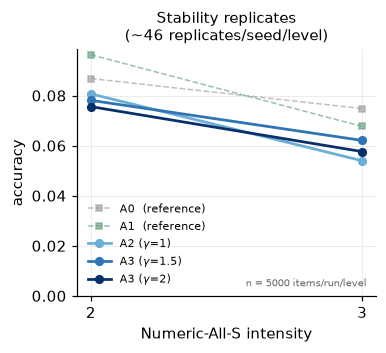

In [14]:
# Figure 1b: Numeric-All-S, the stability replicates. Two intensity levels only,
# but ~46 replicates per seed per level, so these are the most precisely measured
# cells in the benchmark. Kept out of Figure 1 so a 2-point curve is not read as a path.
if "Numeric-All-S" in set(CELL.family):
    fig, ax = plt.subplots(figsize=(3.6, 3.3))
    for run in ORDER:
        c = gamma_curve(run, "Numeric-All-S")
        on_path = run in GAMMA_CURVES.values()
        ax.plot(c.cell, c["mean"],
                marker="o" if on_path else "s", ms=5 if on_path else 4,
                lw=1.8 if on_path else 1.0, ls="-" if on_path else "--",
                color=COLOR[run], alpha=1.0 if on_path else 0.65,
                label=SHORT[run] + ("" if on_path else "  (reference)"))
    ax.set_xticks([2, 3]); ax.set_xlabel("Numeric-All-S intensity")
    ax.set_ylabel("accuracy"); ax.set_ylim(bottom=0)
    ax.set_title("Stability replicates\n(~46 replicates/seed/level)", fontsize=9.5)
    ax.legend(fontsize=7.5)
    n_s = int(IT[IT.family == "Numeric-All-S"].groupby(["run", "intensity"]).size().min())
    ax.text(0.97, 0.03, f"n = {n_s} items/run/level", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=6.8, color="#666")
    fig.tight_layout(); savefig(fig, "fig01b_stability_replicates"); plt.show()

In [15]:
# Per-family per-group quantities used by Figures 2-4 and 7.
FAM_ACC = (IT[~IT.is_original].groupby(["run", "family", "group_id"])["avg_n"]
           .mean().rename("acc").reset_index())

def fam_gap_by_group(run, family):
    '''gap_i = acc_orig_i - mean accuracy of that family's variants for seed i.'''
    sub = FAM_ACC[(FAM_ACC.run == run) & (FAM_ACC.family == family)]
    return {g: ACC_ORIG[run][g] - a for g, a in zip(sub.group_id, sub.acc)
            if g in ACC_ORIG[run]}

def fam_acc_by_group(run, family):
    sub = FAM_ACC[(FAM_ACC.run == run) & (FAM_ACC.family == family)]
    return dict(zip(sub.group_id, sub.acc))

def rsr_parts(run, family=None, arms=None, transfer=None):
    '''Per-group numerator/denominator for RSR and recovery, pooled over the
    variant items in the slice. RSR = sum_i e_i*h_i / sum_i e_i over items.'''
    sub = IT[(IT.run == run) & (~IT.is_original)]
    if family is not None: sub = sub[sub.family == family]
    if arms   is not None: sub = sub[sub.arm.isin(arms)]
    if transfer is not None: sub = sub[sub.family.map(transfer_group) == transfer]
    num_r, den_r, num_c, den_c = {}, {}, {}, {}
    for gid, grp in sub.groupby("group_id"):
        e = E_I[run].get(gid, np.nan)
        h = grp["binarised"].to_numpy(dtype=float)
        m = len(h)
        num_r[gid] = float(e * h.sum());        den_r[gid] = float(e * m)
        num_c[gid] = float((1 - e) * h.sum());  den_c[gid] = float((1 - e) * m)
    return (num_r, den_r), (num_c, den_c)

def transfer_group(family):
    '''Distance from the training perturbations (matches the runs own aggregation).'''
    if family == "Original":            return "original"
    if family.startswith("Numeric"):    return "Numeric (in-family)"
    if family.startswith("Symbolic"):   return "Symbolic (adjacent)"
    if family.startswith("Equivalence"):return "Equivalence (out-of-family)"
    return "other"

TRANSFER_ORDER = ["Numeric (in-family)", "Symbolic (adjacent)", "Equivalence (out-of-family)"]

def grouped_bars(ax, categories, series, ylabel, width=None, annotate_n=None):
    '''series: {run: [(mean, lo, hi), ...]} aligned with categories.'''
    width = BW if width is None else width
    x = np.arange(len(categories))
    k = len(series)
    for i, (run, vals) in enumerate(series.items()):
        m  = np.array([v["mean"] for v in vals], dtype=float)
        lo = np.array([v["lo"] for v in vals], dtype=float)
        hi = np.array([v["hi"] for v in vals], dtype=float)
        off = (i - (k - 1) / 2) * width
        ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    if annotate_n is not None:
        for xi, nn in zip(x, annotate_n):
            ax.annotate(f"n={nn}", (xi, 0), xytext=(0, -34), textcoords="offset points",
                        ha="center", fontsize=6.3, color="#777")
    return ax

---
## Figure 2 — Accuracy by family

**Shows.** Mean accuracy on the originals and on each perturbation family, one bar
per ablation, 95% cluster-bootstrap intervals over `group_id` (B = 10,000, seed 0).

**Conclude.** The headline capability picture: which model solves more problems, and
where. Read it together with Figure 4 — a model that is simply weaker will show a
small gap for trivial reasons, so accuracy alone does not settle robustness.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig02_accuracy_by_family.{pdf,png}


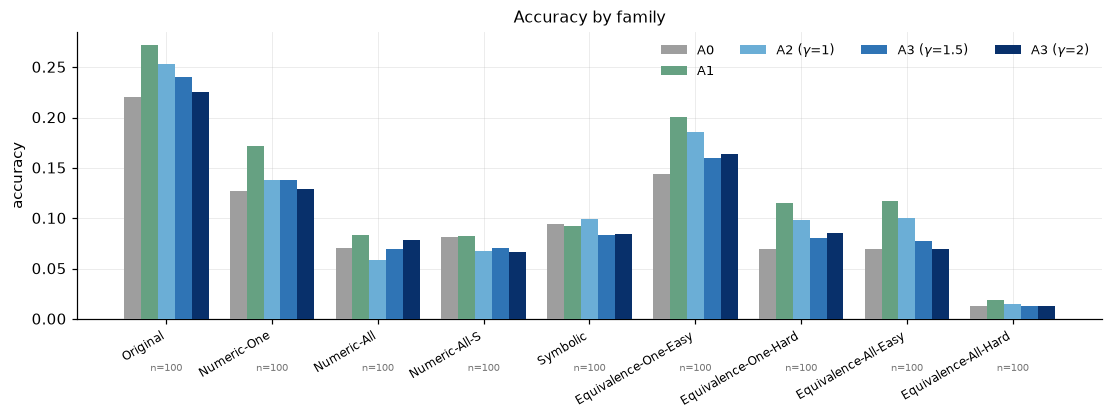

                      n_seeds                   A0                   A1                   A2               A3g1.5                   A3
Original                  100  0.220 [0.151,0.295]  0.272 [0.194,0.352]  0.253 [0.178,0.331]  0.240 [0.170,0.315]  0.225 [0.158,0.297]
Numeric-One               100  0.127 [0.084,0.174]  0.172 [0.120,0.227]  0.138 [0.090,0.190]  0.138 [0.094,0.186]  0.129 [0.086,0.177]
Numeric-All               100  0.071 [0.043,0.102]  0.083 [0.052,0.118]  0.059 [0.032,0.091]  0.070 [0.042,0.104]  0.079 [0.052,0.110]
Numeric-All-S             100  0.081 [0.049,0.118]  0.082 [0.049,0.120]  0.068 [0.036,0.105]  0.070 [0.041,0.105]  0.067 [0.039,0.099]
Symbolic                  100  0.094 [0.054,0.138]  0.092 [0.055,0.135]  0.099 [0.061,0.143]  0.084 [0.049,0.123]  0.084 [0.049,0.123]
Equivalence-One-Easy      100  0.144 [0.097,0.193]  0.201 [0.142,0.264]  0.186 [0.130,0.245]  0.160 [0.110,0.214]  0.164 [0.112,0.218]
Equivalence-One-Hard      100  0.069 [0.044,0.097]  0.1

In [16]:
cats = ["Original"] + FAMILY_ORDER
series, ns = {}, []
for run in ORDER:
    vals = []
    for fam in cats:
        d = ACC_ORIG[run] if fam == "Original" else fam_acc_by_group(run, fam)
        vals.append(cluster_bootstrap(d))
    series[run] = vals
ns = [series["A0"][i]["n"] for i in range(len(cats))]

fig, ax = plt.subplots(figsize=(10.2, 3.9))
grouped_bars(ax, cats, series, "accuracy", annotate_n=ns)
ax.set_title("Accuracy by family")
ax.legend(ncol=4, loc="upper right")
fig.tight_layout(); savefig(fig, "fig02_accuracy_by_family"); plt.show()

F2 = pd.DataFrame({run: [f"{v['mean']:.3f} [{v['lo']:.3f},{v['hi']:.3f}]" for v in series[run]]
                   for run in ORDER}, index=cats)
F2.insert(0, "n_seeds", ns)
print(F2.to_string())
RESULTS["fig2_accuracy_by_family"] = {run: {c: series[run][i] for i, c in enumerate(cats)} for run in ORDER}

---
## Figure 3 — Invariance gap, overall and per family

**Shows.** $\Delta_i = \mathrm{acc}(\text{original}_i) - \overline{\mathrm{acc}}(\text{variants}_i)$,
averaged over seeds, with 95% intervals. Lower is better.

**Conclude.** Whether the penalty narrowed the gap. **Overlapping intervals mean the
runs are not distinguishable on this metric** — marked explicitly below. Note that a
gap can shrink because the variants got better *or* because the originals got worse;
Figures 5 and 6 are what separate the two.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig03_invariance_gap.{pdf,png}


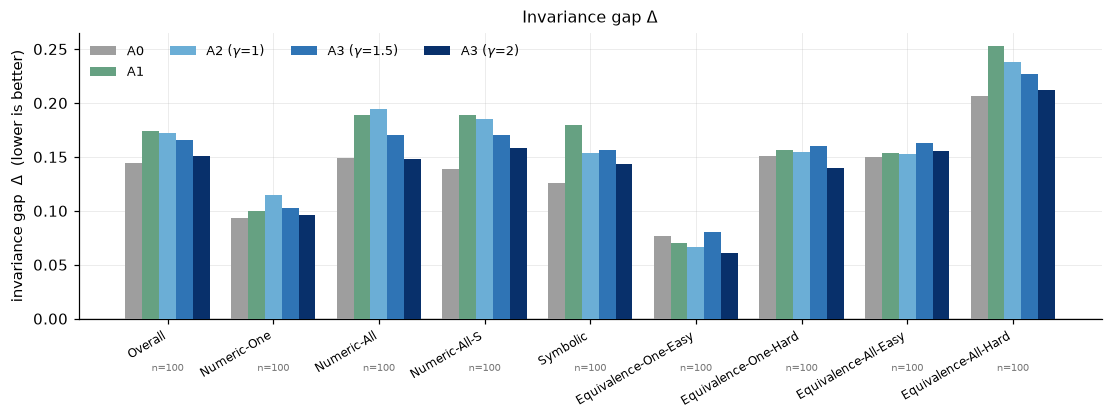

interval overlap between the gamma-path runs (A2 vs A3):
  Overall                    A2 0.172 [0.114, 0.232]   A3 0.151 [0.100, 0.206]   OVERLAP -- not distinguishable
  Numeric-One                A2 0.115 [0.070, 0.164]   A3 0.096 [0.053, 0.143]   OVERLAP -- not distinguishable
  Numeric-All                A2 0.194 [0.132, 0.261]   A3 0.149 [0.093, 0.210]   OVERLAP -- not distinguishable
  Numeric-All-S              A2 0.185 [0.124, 0.252]   A3 0.159 [0.105, 0.217]   OVERLAP -- not distinguishable
  Symbolic                   A2 0.154 [0.104, 0.208]   A3 0.144 [0.095, 0.197]   OVERLAP -- not distinguishable
  Equivalence-One-Easy       A2 0.067 [0.021, 0.115]   A3 0.062 [0.024, 0.104]   OVERLAP -- not distinguishable
  Equivalence-One-Hard       A2 0.155 [0.102, 0.213]   A3 0.140 [0.093, 0.192]   OVERLAP -- not distinguishable
  Equivalence-All-Easy       A2 0.153 [0.093, 0.218]   A3 0.156 [0.105, 0.212]   OVERLAP -- not distinguishable
  Equivalence-All-Hard       A2 0.238 [0.168, 0

In [17]:
cats3 = ["Overall"] + FAMILY_ORDER
series3 = {}
for run in ORDER:
    vals = [cluster_bootstrap(GAP_ALL[run])]
    for fam in FAMILY_ORDER:
        vals.append(cluster_bootstrap(fam_gap_by_group(run, fam)))
    series3[run] = vals

fig, ax = plt.subplots(figsize=(10.2, 3.9))
grouped_bars(ax, cats3, series3, "invariance gap  $\\Delta$  (lower is better)",
             annotate_n=[series3["A0"][i]["n"] for i in range(len(cats3))])
ax.axhline(0, color="#333", lw=0.8)
ax.set_title("Invariance gap $\\Delta$")
ax.legend(ncol=4, loc="upper left")
fig.tight_layout(); savefig(fig, "fig03_invariance_gap"); plt.show()

def overlaps(a, b):
    return not (a["hi"] < b["lo"] or b["hi"] < a["lo"])

print("interval overlap between the gamma-path runs (A2 vs A3):")
for i, c in enumerate(cats3):
    a2, a3 = series3["A2"][i], series3["A3"][i]
    print(f"  {c:<26} A2 {fmt_ci(a2)}   A3 {fmt_ci(a3)}   "
          f"{'OVERLAP -- not distinguishable' if overlaps(a2, a3) else 'disjoint'}")
RESULTS["fig3_gap"] = {run: {c: series3[run][i] for i, c in enumerate(cats3)} for run in ORDER}

---
## Figure 4 — RSR by family, with recovery rate

**Shows.** $\mathrm{RSR} = \Pr[\text{variant correct} \mid \text{original correct}]$
per family per ablation (solid), with the recovery rate
$\Pr[\text{variant correct} \mid \text{original incorrect}]$ as a lighter secondary
bar. Intervals are ratio-of-sums cluster bootstraps.

**Conclude.** RSR conditions capability away, so it is the fair comparison between
models of differing strength — unlike $\Delta$, it cannot be improved by getting
worse at the originals. **Recovery should be near zero**; a non-trivial value means
the perturbation sometimes makes the problem *easier*, and is flagged below.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig04_rsr_by_family.{pdf,png}


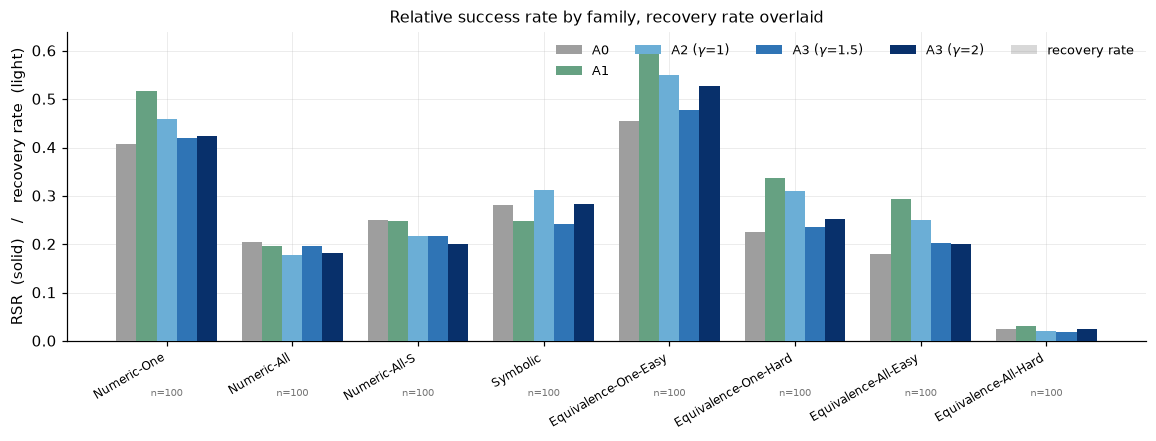

RSR [95% CI]   and recovery rate
  A0
    Numeric-One              RSR 0.407 [0.293, 0.521]   recovery 0.032
    Numeric-All              RSR 0.206 [0.123, 0.299]   recovery 0.020
    Numeric-All-S            RSR 0.250 [0.146, 0.361]   recovery 0.024
    Symbolic                 RSR 0.281 [0.185, 0.387]   recovery 0.005
    Equivalence-One-Easy     RSR 0.454 [0.336, 0.572]   recovery 0.037
    Equivalence-One-Hard     RSR 0.224 [0.156, 0.294]   recovery 0.016
    Equivalence-All-Easy     RSR 0.179 [0.119, 0.244]   recovery 0.019
    Equivalence-All-Hard     RSR 0.024 [0.010, 0.042]   recovery 0.003
  A1
    Numeric-One              RSR 0.517 [0.401, 0.631]   recovery 0.044
    Numeric-All              RSR 0.196 [0.120, 0.288]   recovery 0.025
    Numeric-All-S            RSR 0.248 [0.151, 0.355]   recovery 0.020
    Symbolic                 RSR 0.248 [0.134, 0.384]   recovery 0.005
    Equivalence-One-Easy     RSR 0.609 [0.487, 0.725]   recovery 0.056   <-- NON-TRIVIAL RECOVERY
    Equ

In [18]:
fig, ax = plt.subplots(figsize=(10.6, 4.1))
x, width = np.arange(len(FAMILY_ORDER)), BW
rsr_tab, rec_tab, flags = {}, {}, []
for i, run in enumerate(ORDER):
    rs, rc = [], []
    for fam in FAMILY_ORDER:
        (nr, dr), (nc, dc) = rsr_parts(run, family=fam)
        rs.append(ratio_cluster_bootstrap(nr, dr))
        rc.append(ratio_cluster_bootstrap(nc, dc))
    rsr_tab[run], rec_tab[run] = rs, rc
    off = boff(i)
    m  = np.array([v["mean"] for v in rs], dtype=float)
    lo = np.array([v["lo"] for v in rs], dtype=float)
    hi = np.array([v["hi"] for v in rs], dtype=float)
    ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    ax.bar(x + off, [v["mean"] for v in rc], width * 0.55, color=COLOR[run],
           alpha=0.32, zorder=4, edgecolor="none")

ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("RSR  (solid)   /   recovery rate  (light)")
ax.set_title("Relative success rate by family, recovery rate overlaid")
h, l = ax.get_legend_handles_labels()
h.append(Patch(facecolor="#888", alpha=0.32)); l.append("recovery rate")
ax.legend(h, l, ncol=5, loc="upper right")
for xi, fam in zip(x, FAMILY_ORDER):
    nn = int(IT[(IT.run == "A0") & (IT.family == fam)].group_id.nunique())
    ax.annotate(f"n={nn}", (xi, 0), xytext=(0, -36), textcoords="offset points",
                ha="center", fontsize=6.3, color="#777")
fig.tight_layout(); savefig(fig, "fig04_rsr_by_family"); plt.show()

print("RSR [95% CI]   and recovery rate")
for run in ORDER:
    print(f"  {run}")
    for fam, r, c in zip(FAMILY_ORDER, rsr_tab[run], rec_tab[run]):
        warn = "   <-- NON-TRIVIAL RECOVERY" if (c["mean"] == c["mean"] and c["mean"] > 0.05) else ""
        if warn: flags.append((run, fam, c["mean"]))
        print(f"    {fam:<24} RSR {fmt_ci(r)}   recovery {c['mean']:.3f}{warn}")
print("\nrecovery > 0.05 anywhere:", "YES -- " + str(flags) if flags else
      "no. Perturbation never systematically makes a problem easier; RSR is safe to read.")
RESULTS["fig4_recovery_flags"] = [{"run": r, "family": f, "recovery": float(v)} for r, f, v in flags]
RESULTS["fig4_rsr"] = {run: {f: rsr_tab[run][i] for i, f in enumerate(FAMILY_ORDER)} for run in ORDER}
RESULTS["fig4_recovery"] = {run: {f: rec_tab[run][i] for i, f in enumerate(FAMILY_ORDER)} for run in ORDER}

---
## Figure 5 — Capability versus invariance

**Shows.** x = accuracy on originals, y = invariance gap $\Delta$, one point per
ablation, 95% intervals on both axes. The arrow traces the γ path from A2 to A3.

**Conclude.** The trade-off in one panel. Down-and-left is the diagnostic position:
**A3 left of A2 (worse accuracy) without being below it (better gap) is levelling
down**, made visible without argument. Up-and-left would be a genuine trade;
down-and-right would be a free lunch.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig05_capability_vs_invariance.{pdf,png}


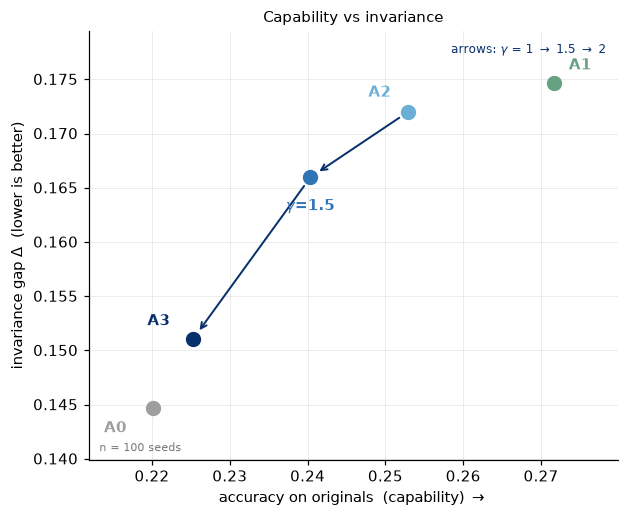

point estimates with 95% cluster-bootstrap intervals:
  A0      acc(orig) 0.220 [0.151, 0.295]   gap 0.145 [0.091, 0.203]
  A1      acc(orig) 0.272 [0.194, 0.352]   gap 0.175 [0.115, 0.236]
  A2      acc(orig) 0.253 [0.178, 0.331]   gap 0.172 [0.114, 0.232]
  A3g1.5  acc(orig) 0.240 [0.170, 0.315]   gap 0.166 [0.111, 0.225]
  A3      acc(orig) 0.225 [0.158, 0.297]   gap 0.151 [0.100, 0.206]

A3 - A2:  acc(orig) -0.0276   gap -0.0209
position of A3 relative to A2: LEFT (less capable) and BELOW (smaller gap)


In [19]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
# A0 and A3 land almost on top of each other, which is itself the result, so the
# labels are offset by hand to keep both readable.
LBL_OFF = {"A0": (-32, -16), "A1": (10, 9), "A2": (-26, 10), "A3g1.5": (-16, -22), "A3": (-30, 9)}
LBL_TXT = {"A3g1.5": "$\\gamma$=1.5", "A3": "A3"}
pts = {}
for run in ORDER:
    a = cluster_bootstrap(ACC_ORIG[run]); g = cluster_bootstrap(GAP_ALL[run])
    pts[run] = (a, g)
    ax.plot(a["mean"], g["mean"], "o", ms=9, color=COLOR[run], zorder=3)
    ax.annotate(LBL_TXT.get(run, run), (a["mean"], g["mean"]), xytext=LBL_OFF[run],
                textcoords="offset points", fontsize=10, weight="bold", color=COLOR[run])

a2, a3 = pts["A2"][0]["mean"], pts["A3"][0]["mean"]
g2, g3 = pts["A2"][1]["mean"], pts["A3"][1]["mean"]
for r0, r1 in zip(list(GAMMA_CURVES.values())[:-1], list(GAMMA_CURVES.values())[1:]):
    ax.annotate("", xy=(pts[r1][0]["mean"], pts[r1][1]["mean"]),
                xytext=(pts[r0][0]["mean"], pts[r0][1]["mean"]),
                arrowprops=dict(arrowstyle="->", color="#08306B", lw=1.3,
                                shrinkA=7, shrinkB=7), zorder=2)
ax.text(0.98, 0.97, "arrows: $\\gamma$ = 1 $\\rightarrow$ 1.5 $\\rightarrow$ 2",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#08306B")
ax.margins(0.16)
ax.set_xlabel("accuracy on originals  (capability) $\\rightarrow$")
ax.set_ylabel("invariance gap $\\Delta$  (lower is better)")
ax.set_title("Capability vs invariance", fontsize=10)
ax.text(0.02, 0.02, f"n = {pts['A0'][0]['n']} seeds", transform=ax.transAxes,
        fontsize=7, color="#777")
fig.tight_layout(); savefig(fig, "fig05_capability_vs_invariance"); plt.show()

d_acc = a3 - a2; d_gap = g3 - g2
print("point estimates with 95% cluster-bootstrap intervals:")
for r in ORDER:
    print(f"  {r:<7} acc(orig) {fmt_ci(pts[r][0])}   gap {fmt_ci(pts[r][1])}")
print()
print(f"A3 - A2:  acc(orig) {d_acc:+.4f}   gap {d_gap:+.4f}")
print("position of A3 relative to A2: "
      + ("LEFT (less capable)" if d_acc < 0 else "RIGHT (more capable)") + " and "
      + ("BELOW (smaller gap)" if d_gap < 0 else "ABOVE (larger gap)"))
RESULTS["fig5_points"] = {r: {"acc_orig": pts[r][0], "gap": pts[r][1]} for r in ORDER}

---
## Figure 6 — Within-seed variance beside accuracy

**Shows.** Two panels on a shared ablation axis: left, within-seed variance of
variant accuracy; right, mean accuracy across all variant arms. Both with 95% intervals.

**Conclude.** This pairing is essential and neither panel means anything alone. A
variance penalty is *supposed* to lower the left panel. It only counts as success if
the right panel does not fall with it: **variance that drops because every accuracy
dropped is equalising downward, not invariance.** Read the two together, and compare
both against A0, which had no training at all.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig06_variance_vs_accuracy.{pdf,png}


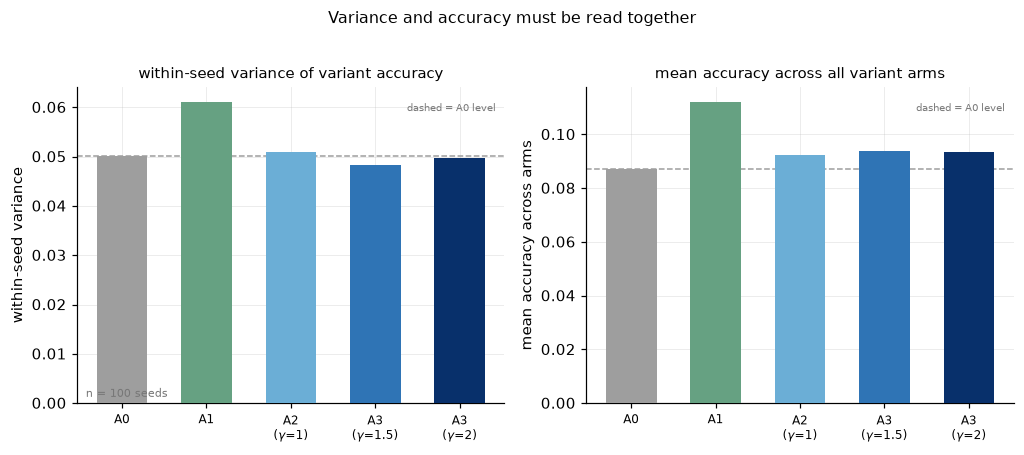

run   within-seed variance          mean acc across arms
A0    0.0500 [0.0353, 0.0657]       0.0872 [0.0575, 0.1205]
A1    0.0610 [0.0446, 0.0781]       0.1120 [0.0766, 0.1507]
A2    0.0509 [0.0365, 0.0659]       0.0923 [0.0597, 0.1294]
A3g1.5    0.0484 [0.0345, 0.0630]       0.0939 [0.0625, 0.1292]
A3    0.0497 [0.0355, 0.0646]       0.0933 [0.0629, 0.1274]

A3 vs A2: variance -0.0012, accuracy +0.0010
A3 vs A0: variance -0.0004, accuracy +0.0062


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.0))
x = np.arange(len(ORDER))

wv = {r: cluster_bootstrap(WVAR[r]) for r in ORDER}
av = {r: cluster_bootstrap(ACC_VARS[r]) for r in ORDER}

for ax, vals, ylab, title in [
        (axes[0], wv, "within-seed variance", "within-seed variance of variant accuracy"),
        (axes[1], av, "mean accuracy across arms", "mean accuracy across all variant arms")]:
    m  = np.array([vals[r]["mean"] for r in ORDER])
    lo = np.array([vals[r]["lo"] for r in ORDER])
    hi = np.array([vals[r]["hi"] for r in ORDER])
    ax.bar(x, m, 0.6, color=[COLOR[r] for r in ORDER], zorder=3)
    ax.axhline(vals["A0"]["mean"], color="#9E9E9E", ls="--", lw=1.0, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[r].replace(" (", "\n(") for r in ORDER], fontsize=8)
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=9.5)
    ax.text(0.98, 0.95, "dashed = A0 level", transform=ax.transAxes, ha="right",
            va="top", fontsize=6.8, color="#777")

axes[0].text(0.02, 0.02, f"n = {wv['A0']['n']} seeds", transform=axes[0].transAxes,
             fontsize=7, color="#777")
fig.suptitle("Variance and accuracy must be read together", y=1.02, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig06_variance_vs_accuracy"); plt.show()

print("run   within-seed variance          mean acc across arms")
for r in ORDER:
    print(f"{r}    {fmt_ci(wv[r],4):<28}  {fmt_ci(av[r],4)}")
print(f"\nA3 vs A2: variance {wv['A3']['mean'] - wv['A2']['mean']:+.4f}, "
      f"accuracy {av['A3']['mean'] - av['A2']['mean']:+.4f}")
print(f"A3 vs A0: variance {wv['A3']['mean'] - wv['A0']['mean']:+.4f}, "
      f"accuracy {av['A3']['mean'] - av['A0']['mean']:+.4f}")
RESULTS["fig6"] = {"within_var": wv, "acc_across_arms": av}

---
## Figure 7 — Transfer by distance from training

**Shows.** $\Delta$ and RSR for three buckets, ordered by distance from the training
perturbations:

1. **Numeric** — matches the `kernel` perturbation seen in training (in-family)
2. **Symbolic** — matches surface renaming (adjacent)
3. **Equivalence** — out of family; nothing in training resembles it

**Conclude.** Anchor regression guarantees robustness only within the span of the
training anchors, so **Equivalence is where the theory predicts nothing**. A3 beating
A2 there would be the interesting result — evidence the penalty bought something
beyond the perturbations it was trained on rather than memorising them.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig07_transfer.{pdf,png}


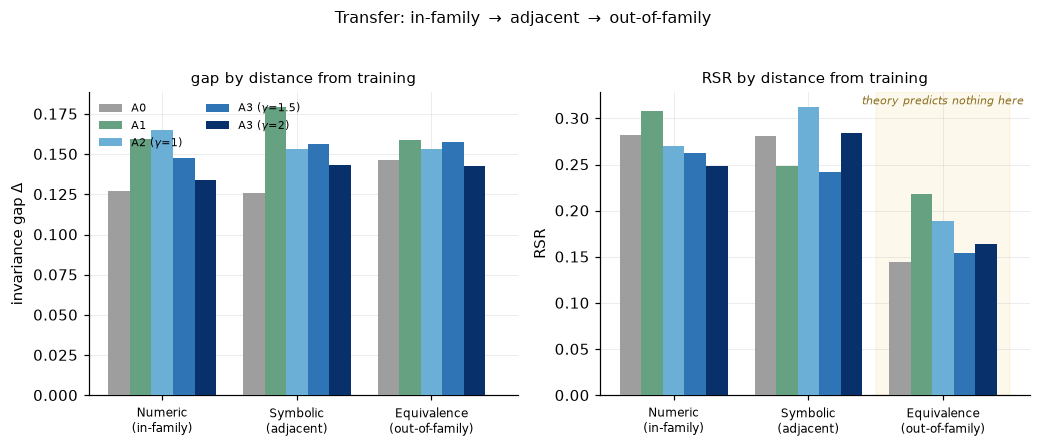

bucket                                    A0                        A1                        A2                      A3g1.5                      A3           
Numeric (in-family)              0.127 [0.077, 0.181]      0.159 [0.103, 0.220]      0.165 [0.110, 0.224]      0.148 [0.096, 0.203]      0.134 [0.085, 0.188]  
Symbolic (adjacent)              0.126 [0.076, 0.180]      0.180 [0.121, 0.243]      0.154 [0.104, 0.208]      0.156 [0.106, 0.212]      0.144 [0.095, 0.197]  
Equivalence (out-of-family)      0.146 [0.093, 0.204]      0.159 [0.104, 0.218]      0.153 [0.099, 0.212]      0.158 [0.106, 0.214]      0.142 [0.095, 0.194]  

Out-of-family, A3 - A2:  gap -0.0108   RSR -0.0249


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), sharex=True)
x, width = np.arange(len(TRANSFER_ORDER)), BW
tr_gap, tr_rsr = {}, {}
for i, run in enumerate(ORDER):
    gaps, rsrs = [], []
    for t in TRANSFER_ORDER:
        fams = [f for f in IT.family.dropna().unique() if transfer_group(f) == t]
        sub = FAM_ACC[(FAM_ACC.run == run) & (FAM_ACC.family.isin(fams))]
        per_g = sub.groupby("group_id")["acc"].mean()
        gaps.append(cluster_bootstrap({g: ACC_ORIG[run][g] - a for g, a in per_g.items()}))
        (nr, dr), _ = rsr_parts(run, transfer=t)
        rsrs.append(ratio_cluster_bootstrap(nr, dr))
    tr_gap[run], tr_rsr[run] = gaps, rsrs
    off = boff(i)
    for ax, vals in [(axes[0], gaps), (axes[1], rsrs)]:
        m  = np.array([v["mean"] for v in vals]); lo = np.array([v["lo"] for v in vals])
        hi = np.array([v["hi"] for v in vals])
        ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)

labels = ["Numeric\n(in-family)", "Symbolic\n(adjacent)", "Equivalence\n(out-of-family)"]
axes[0].set_ylabel("invariance gap $\\Delta$"); axes[0].set_title("gap by distance from training", fontsize=9.5)
axes[1].set_ylabel("RSR"); axes[1].set_title("RSR by distance from training", fontsize=9.5)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
axes[0].legend(ncol=2, fontsize=7.5)
axes[1].axvspan(1.5, 2.5, color="#F2C14E", alpha=0.10, zorder=0)
axes[1].text(2, axes[1].get_ylim()[1] * 0.96, "theory predicts nothing here",
             ha="center", fontsize=7, style="italic", color="#8a6d1f")
fig.suptitle("Transfer: in-family $\\rightarrow$ adjacent $\\rightarrow$ out-of-family", y=1.03, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig07_transfer"); plt.show()

print(f"{'bucket':<30} " + "  ".join(f"{r:^24}" for r in ORDER))
for j, t in enumerate(TRANSFER_ORDER):
    print(f"{t:<30} " + "  ".join(f"{fmt_ci(tr_gap[r][j]):^24}" for r in ORDER))
oof = TRANSFER_ORDER.index("Equivalence (out-of-family)")
print(f"\nOut-of-family, A3 - A2:  gap {tr_gap['A3'][oof]['mean'] - tr_gap['A2'][oof]['mean']:+.4f}   "
      f"RSR {tr_rsr['A3'][oof]['mean'] - tr_rsr['A2'][oof]['mean']:+.4f}")
RESULTS["fig7_transfer"] = {"gap": {r: {TRANSFER_ORDER[j]: tr_gap[r][j] for j in range(3)} for r in ORDER},
                            "rsr": {r: {TRANSFER_ORDER[j]: tr_rsr[r][j] for j in range(3)} for r in ORDER}}

---
## Figure 8 — $\hat{R}$ by family and global

**Shows.** The MATH-Perturb saturating robustness score per family and globally,
as horizontal bars, **each annotated with its own $\beta$**.

**Conclude.** $\hat{R}$ rescales itself to the typical drop it observes:
$\beta = \ln 2 / \tilde d$, where $\tilde d$ is the median positive drop. Two
$\hat{R}$ values computed under different $\beta$ are not on the same scale, so
**$\hat{R}$ is not comparable across benchmarks, or across families, without $\beta$
beside it**. The annotation is the point of the figure, not decoration.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig08_rhat.{pdf,png}


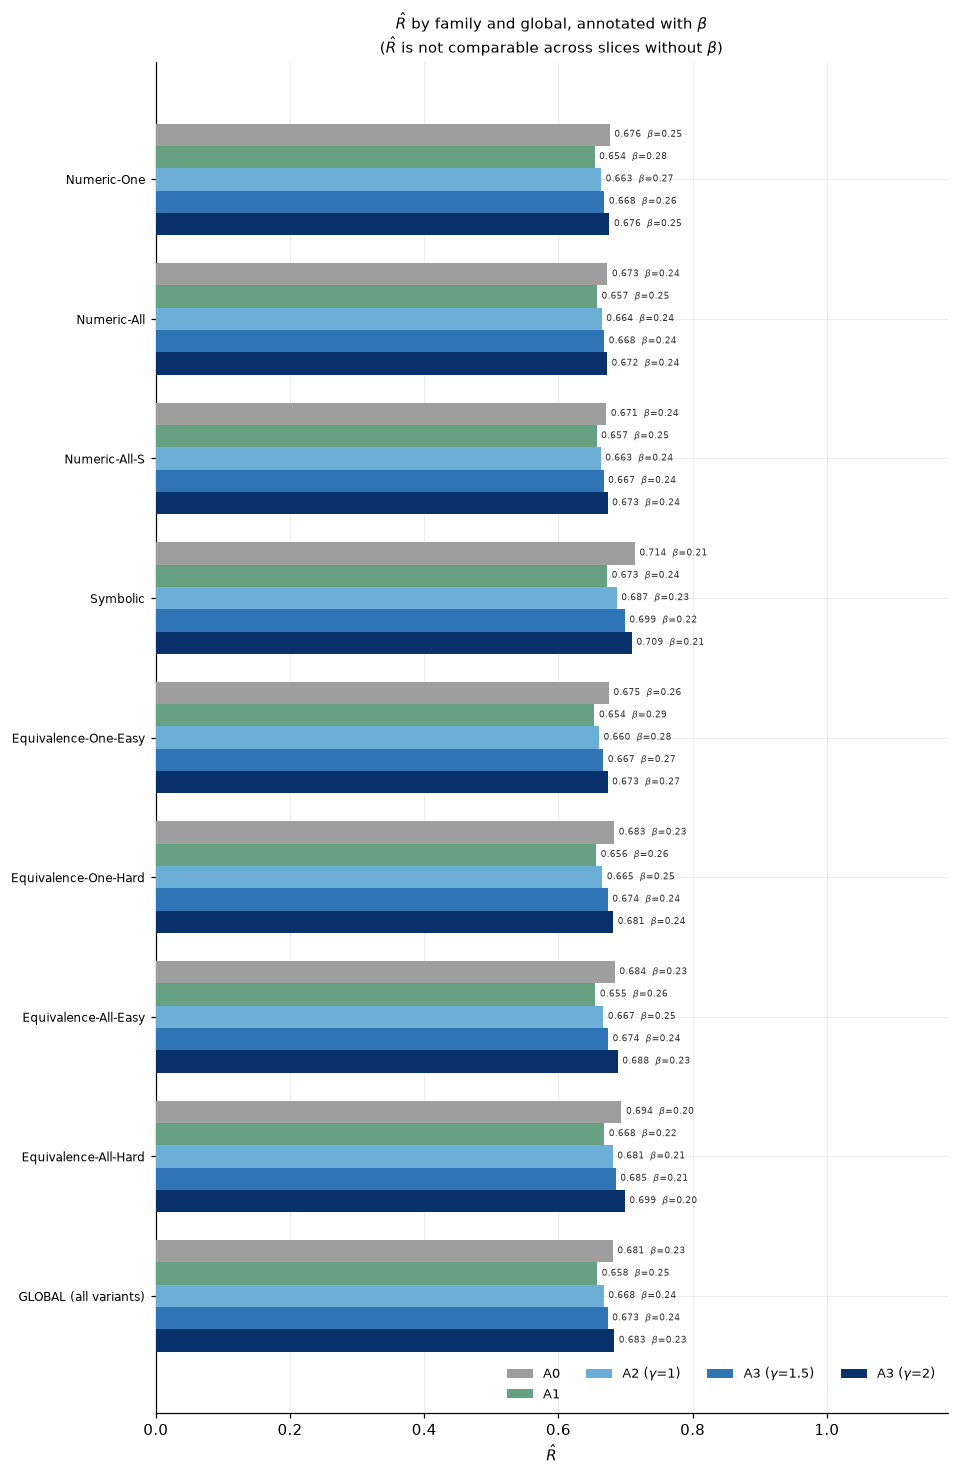

run                                  A0        A1        A2        A3    A3g1.5
slice                                                                          
Numeric-One                    0.676498  0.653863  0.663482  0.675978  0.668247
Numeric-All                    0.672899  0.657431  0.664430  0.672277  0.668069
Numeric-All-S                  0.671262  0.656820  0.663010  0.673216  0.667272
Symbolic                       0.713836  0.672535  0.686856  0.709364  0.698831
Equivalence-One-Easy           0.675204  0.653534  0.660427  0.673167  0.666710
Equivalence-One-Hard           0.682985  0.656199  0.665327  0.681444  0.673517
Equivalence-All-Easy           0.684004  0.654950  0.666801  0.688381  0.673888
Equivalence-All-Hard           0.693941  0.668278  0.680867  0.698801  0.685352
GLOBAL (all variants)          0.681044  0.657542  0.667527  0.683043  0.673282
global (surf x para, summary)  0.673821  0.655598  0.661671  0.672971  0.667764

beta spread across slices (why R-hat ne

In [22]:
sys.path.insert(0, data["A0"]["eval_dir"])
for _m in ("metrics",):
    sys.modules.pop(_m, None)
import metrics as M
sys.path.remove(data["A0"]["eval_dir"])

def rhat_for(run, family=None):
    sub = IT[(IT.run == run) & (~IT.is_original)]
    if family is not None:
        sub = sub[sub.family == family]
    e = [E_I[run][g] for g in sub.group_id]
    h = sub["binarised"].tolist()
    return M.r_hat(e, h)

rows8 = []
for run in ORDER:
    for fam in FAMILY_ORDER:
        rr = rhat_for(run, fam); rows8.append({"run": run, "slice": fam, **rr})
    rr = rhat_for(run); rows8.append({"run": run, "slice": "GLOBAL (all variants)", **rr})
    s = data[run]["summary"]
    rows8.append({"run": run, "slice": "global (surf x para, summary)",
                  "r_hat": s["r_hat_global"], "beta": np.nan, "d_tilde": np.nan, "N": np.nan})
R8 = pd.DataFrame(rows8)

slices = FAMILY_ORDER + ["GLOBAL (all variants)"]
fig, ax = plt.subplots(figsize=(8.8, 0.52 * len(slices) * len(ORDER) / 2 + 1.8))
y, h_ = np.arange(len(slices)), BW
for i, run in enumerate(ORDER):
    sub = R8[(R8.run == run) & (R8.slice.isin(slices))].set_index("slice").loc[slices]
    off = boff(i)
    ax.barh(y + off, sub.r_hat, h_, color=COLOR[run], label=SHORT[run], zorder=3)
    for yy, (v, b) in zip(y + off, zip(sub.r_hat, sub.beta)):
        ax.annotate(f"{v:.3f}  " + (r"$\beta$=" + f"{b:.2f}" if np.isfinite(b) else r"$\beta$=n/a"),
                    (v, yy), xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=6.2, color="#333")
ax.set_yticks(y); ax.set_yticklabels(slices, fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("$\\hat{R}$"); ax.set_xlim(0, 1.18)
ax.set_title("$\\hat{R}$ by family and global, annotated with $\\beta$\n"
             "($\\hat{R}$ is not comparable across slices without $\\beta$)", fontsize=10)
ax.legend(ncol=4, loc="lower right")
fig.tight_layout(); savefig(fig, "fig08_rhat"); plt.show()

print(R8.pivot_table(index="slice", columns="run", values="r_hat").reindex(
      slices + ["global (surf x para, summary)"]).to_string())
print("\nbeta spread across slices (why R-hat needs it):")
print(R8[R8.slice.isin(slices)].pivot_table(index="slice", columns="run", values="beta").to_string())
RESULTS["fig8_rhat"] = R8.to_dict("records")

---
## Figure 9 — G-Pass@8 reliability profile

**Shows.** G-Pass@8 at $\tau \in \{0.5, 0.75, 1.0\}$ per ablation, annotated with
mG-Pass@8.

**Conclude.** This separates *can solve* from *solves dependably*. Pass@1 counts a
problem solved if one of eight samples landed; G-Pass@$8_{\tau=1.0}$ requires all
eight. The decay from $\tau{=}0.5$ to $\tau{=}1.0$ is the reliability profile.

**Originals only.** The manifest records `n_samples = 8 originals / 1 variants`: every
variant was generated once, so no multi-sample reliability metric is defined on them.
The per-family breakdown the brief asks for is not computable from this data, and is
not faked here. This is verified rather than assumed in the first line below.

n_attempted by is_original:
              min  max  median
is_original                  
False          1    1     1.0
True           8    8     8.0

variants have >=8 samples: False -> G-Pass restricted to ORIGINALS


saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig09_gpass.{pdf,png}


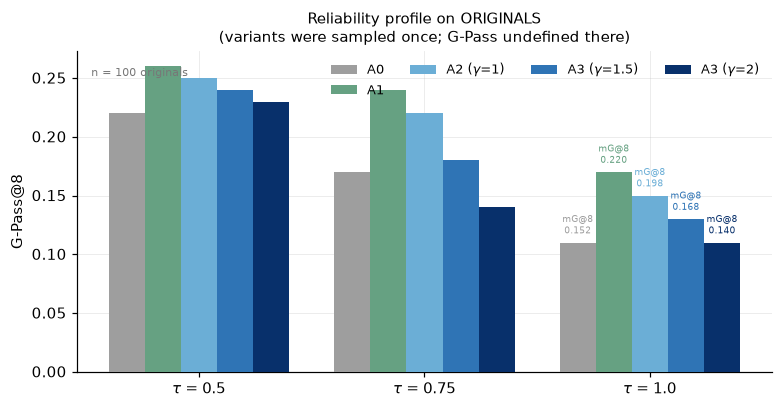


run                   G@8 t=0.5                G@8 t=0.75                 G@8 t=1.0   mG-Pass@8
A0         0.220 [0.140, 0.300]      0.170 [0.100, 0.250]      0.110 [0.050, 0.180]      0.1525
A1         0.260 [0.180, 0.350]      0.240 [0.160, 0.330]      0.170 [0.100, 0.250]      0.2200
A2         0.250 [0.170, 0.340]      0.220 [0.140, 0.300]      0.150 [0.080, 0.220]      0.1975
A3g1.5      0.240 [0.160, 0.320]      0.180 [0.110, 0.260]      0.130 [0.070, 0.200]      0.1675
A3         0.230 [0.150, 0.310]      0.140 [0.080, 0.210]      0.110 [0.050, 0.170]      0.1400


In [23]:
n_att = IT.groupby("is_original")["n_attempted"].agg(["min", "max", "median"])
print("n_attempted by is_original:\n", n_att.to_string())
VARIANTS_MULTISAMPLE = bool(n_att.loc[False, "max"] >= 8)
print(f"\nvariants have >=8 samples: {VARIANTS_MULTISAMPLE} -> "
      f"{'per-family G-Pass is computable' if VARIANTS_MULTISAMPLE else 'G-Pass restricted to ORIGINALS'}")

TAUS = [0.5, 0.75, 1.0]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
x, width = np.arange(len(TAUS)), BW
gp = {}
for i, run in enumerate(ORDER):
    o = IT[(IT.run == run) & (IT.is_original)]
    vals = [cluster_bootstrap(dict(zip(o.group_id, o[f"g_pass_at_8_{t}"]))) for t in TAUS]
    gp[run] = vals
    off = boff(i)
    m  = np.array([v["mean"] for v in vals]); lo = np.array([v["lo"] for v in vals])
    hi = np.array([v["hi"] for v in vals])
    ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    mg = float(o["mg_pass_at_8"].mean())
    ax.annotate(f"mG@8\n{mg:.3f}", (x[-1] + off, m[-1]), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=6.2, color=COLOR[run])

ax.set_xticks(x); ax.set_xticklabels([f"$\\tau$ = {t}" for t in TAUS])
ax.set_ylabel("G-Pass@8"); ax.legend(ncol=4)
ax.set_title("Reliability profile on ORIGINALS\n"
             "(variants were sampled once; G-Pass undefined there)", fontsize=10)
ax.text(0.02, 0.95, f"n = {gp['A0'][0]['n']} originals", transform=ax.transAxes,
        fontsize=7, color="#777", va="top")
fig.tight_layout(); savefig(fig, "fig09_gpass"); plt.show()

print(f"\n{'run':<5}" + "".join(f"{'G@8 t=' + str(t):>26}" for t in TAUS) + f"{'mG-Pass@8':>12}")
MG = {}
for run in ORDER:
    o = IT[(IT.run == run) & (IT.is_original)]
    MG[run] = cluster_bootstrap(dict(zip(o.group_id, o["mg_pass_at_8"])))
    print(f"{run:<5}" + "".join(f"{fmt_ci(gp[run][j]):>26}" for j in range(len(TAUS)))
          + f"{MG[run]['mean']:>12.4f}")
RESULTS["fig9_gpass"] = {r: {f"tau_{t}": gp[r][j] for j, t in enumerate(TAUS)} for r in ORDER}
RESULTS["fig9_mgpass8_orig"] = MG

---
## Figure 10 — Generation health

**Shows.** Extract-failure rate, truncation rate and mean completion length, by
ablation and by family.

**Conclude.** This figure defends — or undermines — every number above it. If one
ablation fails to emit a parseable boxed answer far more often than the others, part
of its measured drop is **format compliance, not reasoning**, and must be disclosed
rather than reported as a capability difference.

The aggregation drops unscorable samples from the accuracy denominator
(`avg_n`) rather than counting them wrong, so a high extract-fail rate does not
mechanically depress accuracy — but it does shrink the evidence each number rests on,
and truncation *does* count against accuracy. The sensitivity check below recomputes
accuracy under the opposite convention (`avg_n_strict`, unscorable counted wrong) and
reports the spread between the two.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig10a_generation_health.{pdf,png}


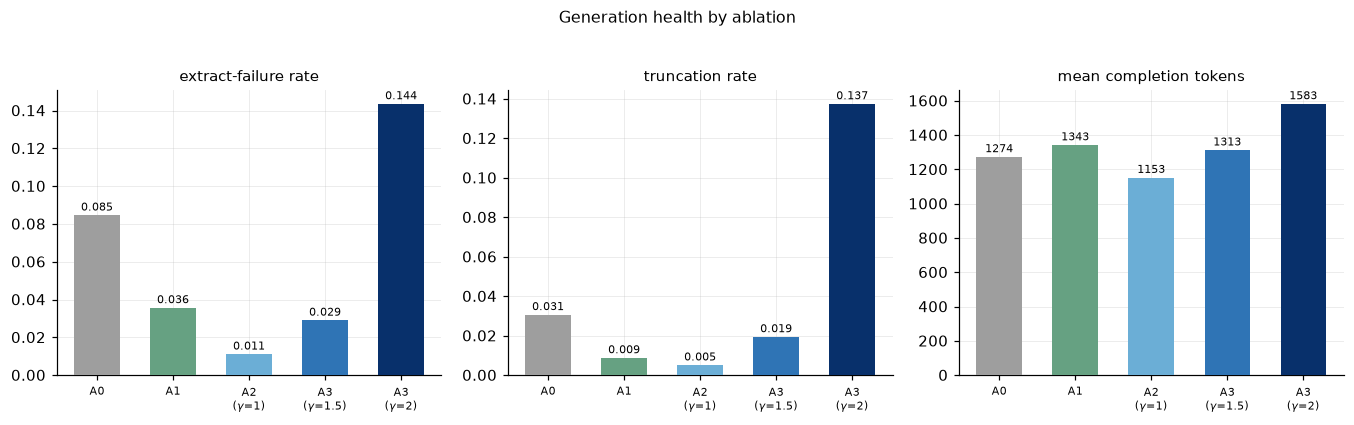

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig10b_generation_health_by_family.{pdf,png}


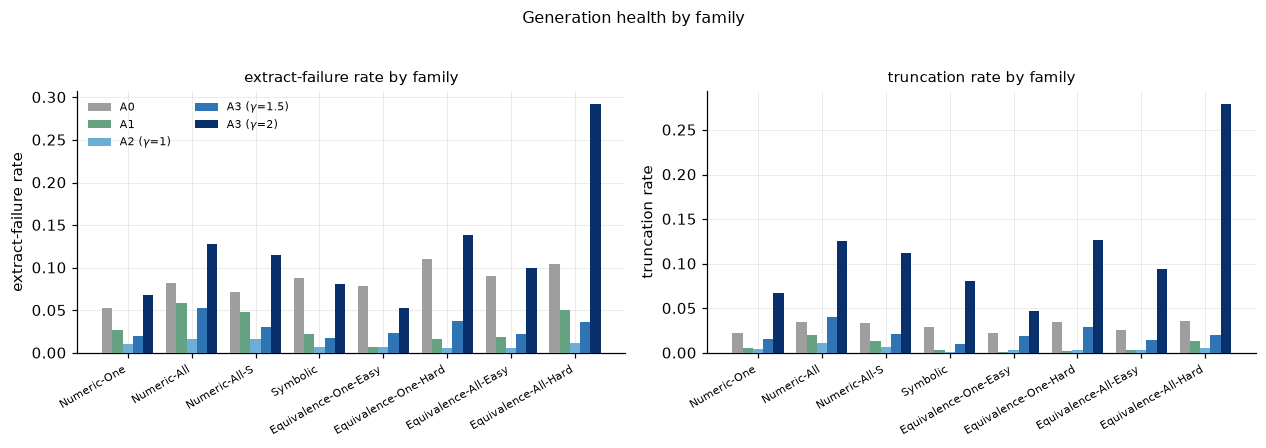

        extract_fail  truncation  format_ok  mean_tokens
A0            0.0847      0.0307     0.9173    1273.9332
A1            0.0357      0.0088     0.9645    1342.9460
A2            0.0112      0.0052     0.9889    1152.9991
A3g1.5        0.0291      0.0195     0.9716    1312.9144
A3            0.1436      0.1375     0.8578    1582.5936

highest extract-fail: A3 at 0.1436 (12.9x the lowest, A2 at 0.0112)

sensitivity -- accuracy under the two unscorable conventions:
        acc  (unscorable dropped)  acc  (unscorable wrong)  spread
A0                         0.0649                   0.0592  0.0057
A1                         0.0880                   0.0847  0.0033
A2                         0.0719                   0.0710  0.0010
A3g1.5                     0.0648                   0.0627  0.0020
A3                         0.0673                   0.0575  0.0098

The spread column is how much of each run's variant accuracy rests on the convention that unscorable samples are dropped ra

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))
metrics10 = [("extract_fail_rate", "extract-failure rate"),
             ("truncation_rate", "truncation rate"),
             ("mean_n_tokens_completion", "mean completion tokens")]
H10 = {}
for ax, (col, lab) in zip(axes, metrics10):
    x = np.arange(len(ORDER))
    vals = [float(IT[IT.run == r][col].mean()) for r in ORDER]
    H10[col] = dict(zip(ORDER, vals))
    ax.bar(x, vals, 0.6, color=[COLOR[r] for r in ORDER], zorder=3)
    for xi, v in zip(x, vals):
        ax.annotate(f"{v:.3f}" if v < 100 else f"{v:.0f}", (xi, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[r].replace(" (", "\n(") for r in ORDER], fontsize=7.5)
    ax.set_title(lab, fontsize=9.5)
fig.suptitle("Generation health by ablation", y=1.03, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig10a_generation_health"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9), sharex=True)
for ax, (col, lab) in zip(axes, metrics10[:2]):
    x, width = np.arange(len(FAMILY_ORDER)), BW
    for i, run in enumerate(ORDER):
        v = [float(IT[(IT.run == run) & (IT.family == f)][col].mean()) for f in FAMILY_ORDER]
        ax.bar(x + boff(i), v, width, color=COLOR[run], label=SHORT[run], zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=30, ha="right", fontsize=7.5)
    ax.set_ylabel(lab); ax.set_title(lab + " by family", fontsize=9.5)
axes[0].legend(ncol=2, fontsize=7.5)
fig.suptitle("Generation health by family", y=1.03, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig10b_generation_health_by_family"); plt.show()

HEALTH = pd.DataFrame({
    "extract_fail": [IT[IT.run == r].extract_fail_rate.mean() for r in ORDER],
    "truncation":   [IT[IT.run == r].truncation_rate.mean() for r in ORDER],
    "format_ok":    [IT[IT.run == r].format_ok_rate.mean() for r in ORDER],
    "mean_tokens":  [IT[IT.run == r].mean_n_tokens_completion.mean() for r in ORDER],
}, index=ORDER)
print(HEALTH.round(4).to_string())

worst = HEALTH.extract_fail.idxmax()
ratio = HEALTH.extract_fail.max() / max(HEALTH.extract_fail.min(), 1e-12)
print(f"\nhighest extract-fail: {worst} at {HEALTH.extract_fail.max():.4f} "
      f"({ratio:.1f}x the lowest, {HEALTH.extract_fail.idxmin()} at {HEALTH.extract_fail.min():.4f})")

print("\nsensitivity -- accuracy under the two unscorable conventions:")
SENS = pd.DataFrame({
    "acc  (unscorable dropped)": [IT[(IT.run == r) & (~IT.is_original)].avg_n.mean() for r in ORDER],
    "acc  (unscorable wrong)":   [IT[(IT.run == r) & (~IT.is_original)].avg_n_strict.mean() for r in ORDER],
}, index=ORDER)
SENS["spread"] = SENS.iloc[:, 0] - SENS.iloc[:, 1]
print(SENS.round(4).to_string())
print("\nThe spread column is how much of each run's variant accuracy rests on the "
      "convention that unscorable samples are dropped rather than counted wrong.")
RESULTS["fig10_health"] = HEALTH.to_dict("index")
RESULTS["fig10_sensitivity"] = SENS.to_dict("index")

---
## Figure 11 — Confidence by family and correctness

**Shows.** Mean token-level confidence $\exp(\frac{1}{n}\sum \log p)$, split by family
and by whether the item was solved. Built only if `mean_confidence` is populated —
checked first, and skipped with a printed statement if not.

**Conclude.** A well-calibrated model is more confident when it is right. A model
equally confident on items it fails is not tracking its own competence, and the gap
between the two bars is a crude calibration read.

mean_confidence populated: True (176840/176840 items non-NaN)


saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig11_confidence.{pdf,png}


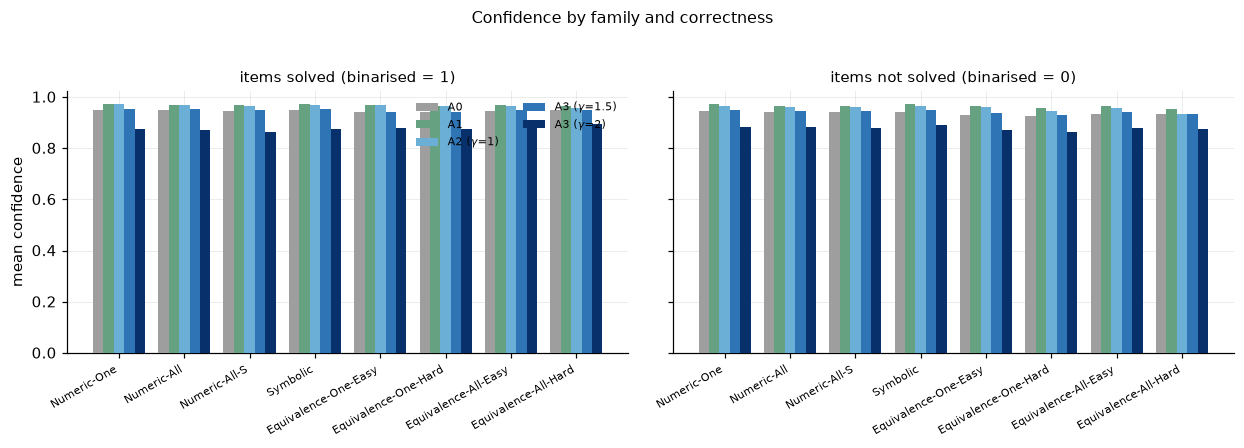

        solved  unsolved  separation
A0      0.9470    0.9365      0.0105
A1      0.9700    0.9628      0.0073
A2      0.9675    0.9539      0.0137
A3g1.5  0.9493    0.9408      0.0085
A3      0.8756    0.8785     -0.0029


In [25]:
conf_ok = bool(IT.mean_confidence.notna().any())
print(f"mean_confidence populated: {conf_ok} "
      f"({int(IT.mean_confidence.notna().sum())}/{len(IT)} items non-NaN)")

if not conf_ok:
    print("mean_confidence is entirely NaN in these runs -- Figure 11 is not available "
          "and is omitted rather than approximated.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.9), sharey=True)
    x, width = np.arange(len(FAMILY_ORDER)), BW
    for ax, solved, title in [(axes[0], 1, "items solved (binarised = 1)"),
                              (axes[1], 0, "items not solved (binarised = 0)")]:
        for i, run in enumerate(ORDER):
            v = []
            for f in FAMILY_ORDER:
                s = IT[(IT.run == run) & (IT.family == f) & (IT.binarised == solved)]
                v.append(float(s.mean_confidence.mean()) if len(s) else np.nan)
            ax.bar(x + boff(i), v, width, color=COLOR[run], label=SHORT[run], zorder=3)
        ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=30, ha="right", fontsize=7.5)
        ax.set_title(title, fontsize=9.5)
    axes[0].set_ylabel("mean confidence"); axes[0].legend(ncol=2, fontsize=7.5)
    fig.suptitle("Confidence by family and correctness", y=1.03, fontsize=10.5)
    fig.tight_layout(); savefig(fig, "fig11_confidence"); plt.show()

    CONF = pd.DataFrame({
        "solved": [IT[(IT.run == r) & (IT.binarised == 1)].mean_confidence.mean() for r in ORDER],
        "unsolved": [IT[(IT.run == r) & (IT.binarised == 0)].mean_confidence.mean() for r in ORDER],
    }, index=ORDER)
    CONF["separation"] = CONF.solved - CONF.unsolved
    print(CONF.round(4).to_string())
    RESULTS["fig11_confidence"] = CONF.to_dict("index")

---
## Figure 12 — Metrics along the γ path

**Shows.** Six headline quantities against γ for the three runs that are the same
estimator at different penalty strengths — γ = 1 (A2, unpenalised), 1.5 and 2 (A3). A0
(dashed grey) and A1 (dotted green) are horizontal reference lines, not points on the
path. Point estimates only.

**Conclude.** Figure 1 asks whether the penalty trades accuracy for stability *within*
each family; this asks what the whole benchmark does as the dose rises. A genuine
trade-off needs capability to fall while the gap narrows **for a reason other than the
capability falling** — which is why the accuracy panels and the gap panel have to be read
together, and why generation health sits on the same figure. A smooth slide in some
panels with an abrupt break in another says the penalty has more than one failure mode.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig12_gamma_path.{pdf,png}


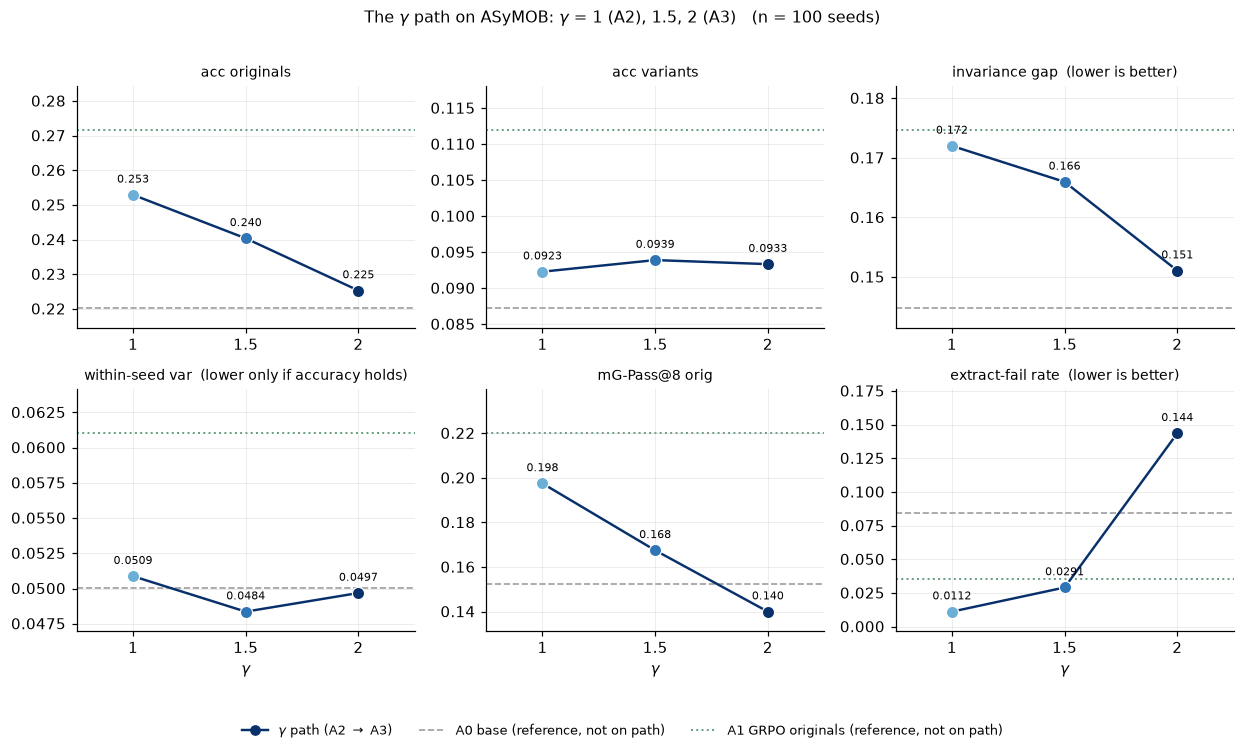

                   gamma=1 (A2)  gamma=1.5 (A3g1.5)  gamma=2 (A3)  A0 (ref)  A1 (ref)
acc originals            0.2529              0.2404        0.2253    0.2201    0.2716
acc variants             0.0923              0.0939        0.0933    0.0872    0.1120
invariance gap           0.1720              0.1660        0.1511    0.1447    0.1747
within-seed var          0.0509              0.0484        0.0497    0.0500    0.0610
mG-Pass@8 orig           0.1975              0.1675        0.1400    0.1525    0.2200
extract-fail rate        0.0112              0.0291        0.1436    0.0847    0.0357

trend along gamma, and the size of each half-step:
  acc originals        monotone DOWN   step 1->1.5 -0.0126   step 1.5->2 -0.0151   second/first =   1.2x
  acc variants         non-monotone    step 1->1.5 +0.0016   step 1.5->2 -0.0006   second/first =   0.3x
  invariance gap       monotone DOWN   step 1->1.5 -0.0060   step 1.5->2 -0.0149   second/first =   2.5x
  within-seed var      non-mono

In [26]:
GAMMAS = {1.0: "A2", 1.5: "A3g1.5", 2.0: "A3"}
GP_METRICS = [
    ("acc originals",      lambda r: cluster_bootstrap(ACC_ORIG[r])["mean"],          "higher"),
    ("acc variants",       lambda r: cluster_bootstrap(ACC_VARS[r])["mean"],          "higher"),
    ("invariance gap",     lambda r: cluster_bootstrap(GAP_ALL[r])["mean"],           "lower"),
    ("within-seed var",    lambda r: cluster_bootstrap(WVAR[r])["mean"],              "lower*"),
    ("mG-Pass@8 orig",     lambda r: RESULTS["fig9_mgpass8_orig"][r]["mean"],         "higher"),
    ("extract-fail rate",  lambda r: float(IT[IT.run == r].extract_fail_rate.mean()), "lower"),
]
GPV = {name: {r: fn(r) for r in ORDER} for name, fn, _ in GP_METRICS}
gammas = sorted(GAMMAS)

fig, axes = plt.subplots(2, 3, figsize=(11.4, 6.4))
for ax, (name, _, better) in zip(axes.ravel(), GP_METRICS):
    ys = [GPV[name][GAMMAS[g]] for g in gammas]
    ax.plot(gammas, ys, "-", color="#08306B", lw=1.6, zorder=2)
    for g, y in zip(gammas, ys):
        ax.plot(g, y, "o", ms=8, color=COLOR[GAMMAS[g]], zorder=3,
                markeredgecolor="white", markeredgewidth=0.8)
        ax.annotate(f"{y:.4f}" if y < 0.1 else f"{y:.3f}", (g, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.4)
    ax.axhline(GPV[name]["A0"], color="#9E9E9E", ls="--", lw=1.1, zorder=1)
    ax.axhline(GPV[name]["A1"], color="#66A182", ls=":", lw=1.3, zorder=1)
    ax.set_xticks(gammas); ax.set_xticklabels([f"{g:g}" for g in gammas])
    ax.set_xlim(gammas[0] - 0.25, gammas[-1] + 0.25)
    lo_, hi_ = ax.get_ylim(); pad = (hi_ - lo_) * 0.18
    ax.set_ylim(lo_ - pad * 0.3, hi_ + pad)
    ax.set_title(name + ("  (lower is better)" if better == "lower" else
                         "  (lower only if accuracy holds)" if better == "lower*" else ""),
                 fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("$\\gamma$")
handles = [Line2D([], [], color="#08306B", marker="o", lw=1.6,
                  label="$\\gamma$ path (A2 $\\rightarrow$ A3)"),
           Line2D([], [], color="#9E9E9E", ls="--", lw=1.1, label="A0 base (reference, not on path)"),
           Line2D([], [], color="#66A182", ls=":", lw=1.3, label="A1 GRPO originals (reference, not on path)")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=8.5)
fig.suptitle(f"The $\\gamma$ path on ASyMOB: $\\gamma$ = 1 (A2), 1.5, 2 (A3)   "
             f"(n = {len(SHARED)} seeds)", y=1.01, fontsize=10.5)
fig.tight_layout(rect=(0, 0.04, 1, 1)); savefig(fig, "fig12_gamma_path"); plt.show()

GP_TAB = pd.DataFrame({f"gamma={g:g} ({GAMMAS[g]})": {k_: GPV[k_][GAMMAS[g]] for k_, _, _ in GP_METRICS}
                       for g in gammas})
GP_TAB["A0 (ref)"] = [GPV[k_]["A0"] for k_, _, _ in GP_METRICS]
GP_TAB["A1 (ref)"] = [GPV[k_]["A1"] for k_, _, _ in GP_METRICS]
print(GP_TAB.round(4).to_string())

def trend(v):
    d = np.diff(v)
    return "monotone DOWN" if (d < 0).all() else "monotone UP" if (d > 0).all() else "non-monotone"

GP_TREND = {k_: trend([GPV[k_][GAMMAS[g]] for g in gammas]) for k_, _, _ in GP_METRICS}
STEPS = {}
for k_, _, _ in GP_METRICS:
    v = [GPV[k_][GAMMAS[g]] for g in gammas]
    STEPS[k_] = {"1->1.5": v[1] - v[0], "1.5->2": v[2] - v[1]}
print("\ntrend along gamma, and the size of each half-step:")
for k_ in GP_TREND:
    st = STEPS[k_]
    ratio = abs(st["1.5->2"]) / max(abs(st["1->1.5"]), 1e-12)
    print(f"  {k_:<20} {GP_TREND[k_]:<15} step 1->1.5 {st['1->1.5']:+.4f}   "
          f"step 1.5->2 {st['1.5->2']:+.4f}   second/first = {ratio:5.1f}x")
RESULTS["fig12_gamma_path"] = {"values": GP_TAB.to_dict("index"), "trend": GP_TREND,
                               "half_steps": STEPS, "gammas": gammas,
                               "path": {f"{g:g}": r for g, r in GAMMAS.items()}}

---
## Figure 13 — The γ trade-off, smoothed: Numeric-All and Symbolic

**Shows.** Accuracy against perturbation intensity for the three γ-path runs
(γ = 1, 1.5, 2), in the two families with the longest measured intensity axes. Each
curve is a **weighted least-squares polynomial fit in log(1 + intensity)** through that
run's per-level accuracies — cubic for Numeric-All's 11 levels, quadratic for Symbolic's
5 — weighted by √n seeds per level so the sparse top of the Symbolic axis cannot drag
the fit. The x-axis is still drawn in raw intensity. A0 is drawn dashed grey as a
reference, not as a point on the path.

**Why log(1 + intensity).** Accuracy falls sharply over the first intensity step and then
flattens. A polynomial in raw intensity cannot follow that shape: in Numeric-All a cubic
wiggles back upward across levels 4–8 and rounds off the real early drop. In
log(1 + intensity) the same cubic fits better (lower weighted RMSE) and never changes
direction. The fits were compared on fit quality, negativity and spurious turning points
before this form was chosen.

**Why smoothed.** The raw per-level curves in Figure 1 zig-zag by several points from
one level to the next — sampling noise at ~100 seeds per level — which hides the
ordering between γ values. The fits show the *trend* each γ follows. They smooth the
data, they do not add information: the measured values and their intervals are in
Figure 1 and the printed table below, and the fit quality (weighted RMSE) is printed so
a poor fit cannot pass unnoticed.

**Conclude.** Anchor regression predicts the curves should *cross*: a larger γ giving
up accuracy at low intensity for stability at high intensity. Read off where the fitted
γ = 1.5 and γ = 2 curves sit relative to γ = 1 at the low and high ends, and where
(if anywhere) they cross — the crossing points are computed from the fits below.

saved  /home/amz/projects/GRIP/ablations/eval/asymob/figures/fig13_gamma_tradeoff_smoothed.{pdf,png}


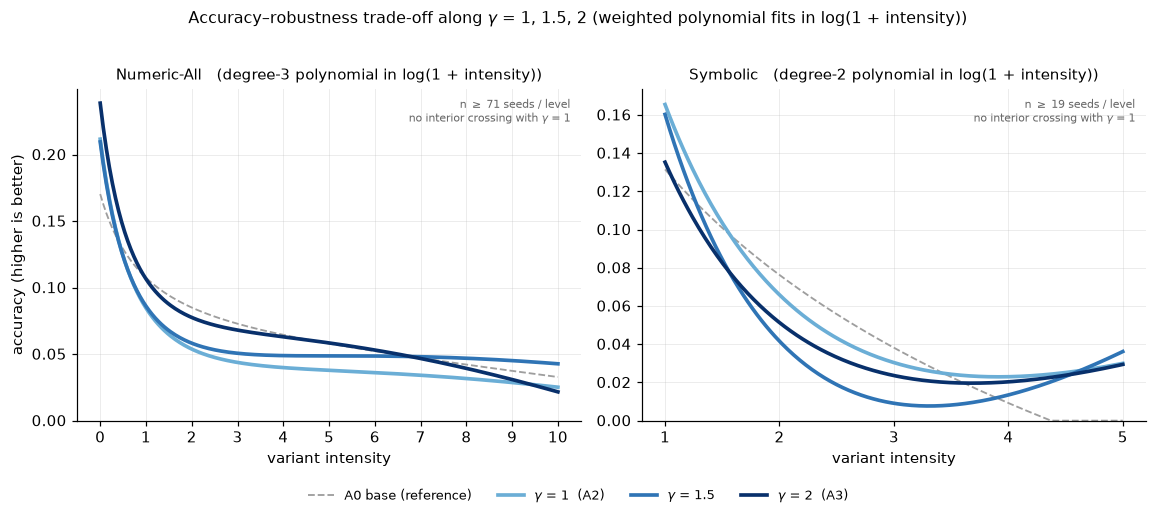


fit quality and fitted-curve comparison against gamma = 1:

  Numeric-All  (degree 3, levels 0-10)
    A2      weighted RMSE 0.0066   fitted acc @ 0: 0.212   @ 10: 0.025
    A3g1.5  weighted RMSE 0.0163   fitted acc @ 0: 0.209   @ 10: 0.043   crosses gamma=1 at: never (interior)
    A3      weighted RMSE 0.0191   fitted acc @ 0: 0.239   @ 10: 0.022   crosses gamma=1 at: never (interior)

  Symbolic  (degree 2, levels 1-5)
    A2      weighted RMSE 0.0072   fitted acc @ 1: 0.165   @ 5: 0.030
    A3g1.5  weighted RMSE 0.0032   fitted acc @ 1: 0.160   @ 5: 0.036   crosses gamma=1 at: never (interior)
    A3      weighted RMSE 0.0115   fitted acc @ 1: 0.135   @ 5: 0.029   crosses gamma=1 at: never (interior)


In [27]:
SMOOTH_PANELS = [("Numeric-All", 3), ("Symbolic", 2)]      # (family, degree in log(1 + x))
TF = np.log1p                                              # fit axis: log(1 + intensity)


def weighted_polyfit(x, y, n, deg):
    '''Least-squares polynomial weighted by sqrt(n) per level; returns coefficients,
    a dense evaluation grid, and the n-weighted RMSE of the fit at the measured levels.'''
    x, y, n = (np.asarray(v, dtype=float) for v in (x, y, n))
    coef = np.polyfit(TF(x), y, deg, w=np.sqrt(n))
    xs = np.linspace(x.min(), x.max(), 300)
    resid = y - np.polyval(coef, TF(x))
    rmse = float(np.sqrt(np.sum(n * resid ** 2) / np.sum(n)))
    return coef, xs, np.clip(np.polyval(coef, TF(xs)), 0, None), rmse


def crossings(coef_a, coef_b, lo, hi, edge=0.10):
    '''Intensities where two fitted curves intersect, found on a dense grid. Crossings in
    the outer 10% of the axis are dropped: two curves that start or end at the same point
    touch there without crossing in any meaningful sense.'''
    xs = np.linspace(lo, hi, 2001)
    d = np.polyval(coef_a, TF(xs)) - np.polyval(coef_b, TF(xs))
    idx = np.where(np.diff(np.sign(d)) != 0)[0]
    span = hi - lo
    return [float(xs[i]) for i in idx if lo + edge * span < xs[i] < hi - edge * span]


fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.2))
SMOOTH = {}
for ax, (fam, deg) in zip(axes, SMOOTH_PANELS):
    ref = gamma_curve("A0", fam)
    _, xs, ys, _ = weighted_polyfit(ref.cell, ref["mean"], ref.n, deg)
    ax.plot(xs, ys, "--", color="#9E9E9E", lw=1.2, zorder=1, label="A0 base (reference)")

    fits = {}
    for lab, run in GAMMA_CURVES.items():
        c = gamma_curve(run, fam)
        coef, xs, ys, rmse = weighted_polyfit(c.cell, c["mean"], c.n, deg)
        fits[run] = {"coef": coef, "rmse": rmse, "levels": c.cell.tolist(),
                     "measured": c["mean"].tolist(), "n": c.n.tolist()}
        ax.plot(xs, ys, "-", color=COLOR[run], lw=2.4, zorder=3, label=lab)
    SMOOTH[fam] = fits

    lo_x, hi_x = min(fits["A2"]["levels"]), max(fits["A2"]["levels"])
    n_cross = 0
    for run in [r for r in GAMMA_CURVES.values() if r != "A2"]:
        for xc in crossings(fits[run]["coef"], fits["A2"]["coef"], lo_x, hi_x):
            ax.axvline(xc, color=COLOR[run], lw=0.8, ls=":", zorder=2); n_cross += 1

    ax.set_title(f"{fam}   (degree-{deg} polynomial in log(1 + intensity))", fontsize=9.5)
    ax.set_xlabel("variant intensity")
    ax.set_xticks(sorted(int(v) for v in fits["A2"]["levels"]))
    ax.set_ylim(bottom=0)
    ax.text(0.98, 0.97, f"n $\\geq$ {int(min(min(f['n']) for f in fits.values()))} seeds / level\n"
            + ("dotted verticals: fitted crossings with $\\gamma$ = 1" if n_cross else
               "no interior crossing with $\\gamma$ = 1"),
            transform=ax.transAxes, ha="right", va="top", fontsize=7, color="#666")
axes[0].set_ylabel("accuracy (higher is better)")
h13, l13 = axes[0].get_legend_handles_labels()
fig.legend(h13, l13, loc="lower center", ncol=len(l13), bbox_to_anchor=(0.5, -0.07), fontsize=8.5)
fig.suptitle("Accuracy–robustness trade-off along $\\gamma$ = 1, 1.5, 2 "
             "(weighted polynomial fits in log(1 + intensity))", y=1.02, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig13_gamma_tradeoff_smoothed")
plt.show()

print("\nfit quality and fitted-curve comparison against gamma = 1:")
for fam, deg in SMOOTH_PANELS:
    fits = SMOOTH[fam]
    lv = fits["A2"]["levels"]; lo_x, hi_x = min(lv), max(lv)
    print(f"\n  {fam}  (degree {deg}, levels {int(lo_x)}-{int(hi_x)})")
    for lab, run in GAMMA_CURVES.items():
        f = fits[run]
        at_lo, at_hi = np.polyval(f["coef"], TF(lo_x)), np.polyval(f["coef"], TF(hi_x))
        line = f"    {run:<7} weighted RMSE {f['rmse']:.4f}   fitted acc @ {int(lo_x)}: {at_lo:.3f}   @ {int(hi_x)}: {at_hi:.3f}"
        if run != "A2":
            xs_ = crossings(f["coef"], fits["A2"]["coef"], lo_x, hi_x)
            line += "   crosses gamma=1 at: " + (", ".join(f"{x:.1f}" for x in xs_) if xs_ else "never (interior)")
        print(line)
RESULTS["fig13_smoothed_tradeoff"] = {
    fam: {run: {"degree": deg, "fit_axis": "log(1 + intensity)",
                "coef": [float(c) for c in SMOOTH[fam][run]["coef"]],
                "weighted_rmse": SMOOTH[fam][run]["rmse"],
                "crossings_with_gamma1": (crossings(SMOOTH[fam][run]["coef"], SMOOTH[fam]["A2"]["coef"],
                                                   min(SMOOTH[fam]["A2"]["levels"]),
                                                   max(SMOOTH[fam]["A2"]["levels"])) if run != "A2" else None)}
          for run in GAMMA_CURVES.values()}
    for fam, deg in SMOOTH_PANELS}

---
## 5. Paired statistical tests

All contrasts run on the seeds shared by both runs, resampling seeds with
`B = 10,000`, `seed = 0`. Shared-seed counts and drops are printed above.

* **A3 − A2 on the gap is the hypothesis test.** An interval excluding zero is the
  evidence that GRIP changed invariance at all.
* **A3 − A0 on accuracy is the levelling-down test.** An interval containing zero
  means A3 is statistically indistinguishable from the *untrained* model.

In [28]:
CONTRASTS = [("A1", "A0"), ("A2", "A0"), ("A2", "A1"),
             ("A3g1.5", "A2"), ("A3", "A2"), ("A3", "A3g1.5"),
             ("A3g1.5", "A0"), ("A3", "A0")]

def rsr_overall_parts(run):
    (nr, dr), _ = rsr_parts(run)
    return nr, dr

rows = []
for a, b in CONTRASTS:
    g  = paired_cluster_bootstrap(GAP_ALL[a],  GAP_ALL[b],  SHARED)
    ao = paired_cluster_bootstrap(ACC_ORIG[a], ACC_ORIG[b], SHARED)
    av = paired_cluster_bootstrap(ACC_VARS[a], ACC_VARS[b], SHARED)
    wv = paired_cluster_bootstrap(WVAR[a],     WVAR[b],     SHARED)
    na, da = rsr_overall_parts(a); nb, db = rsr_overall_parts(b)
    rs = paired_ratio_cluster_bootstrap(na, da, nb, db)
    rows.append({"contrast": f"{a} - {b}", "n_seeds": g["n"],
                 "d_gap": g, "d_acc_orig": ao, "d_acc_var": av,
                 "d_within_var": wv, "d_rsr": rs})

def star(d): return " *" if d.get("significant") else ""

print(f"{'contrast':<12}{'n':>4}   {'Δ gap [95% CI]':<30}{'Δ acc(orig) [95% CI]':<30}{'Δ RSR [95% CI]':<30}")
print("-" * 106)
for r in rows:
    print(f"{r['contrast']:<12}{r['n_seeds']:>4}   "
          f"{fmt_ci(r['d_gap']) + star(r['d_gap']):<30}"
          f"{fmt_ci(r['d_acc_orig']) + star(r['d_acc_orig']):<30}"
          f"{fmt_ci(r['d_rsr']) + star(r['d_rsr']):<30}")
print("\n*  interval excludes zero")
CONTRAST_ROWS = rows
RESULTS["contrasts"] = [{k: v for k, v in r.items()} for r in rows]

contrast       n   Δ gap [95% CI]                Δ acc(orig) [95% CI]          Δ RSR [95% CI]                
----------------------------------------------------------------------------------------------------------
A1 - A0      100   0.030 [0.001, 0.064] *        0.051 [0.017, 0.090] *        0.049 [0.008, 0.084] *        
A2 - A0      100   0.027 [-0.003, 0.061]         0.033 [0.001, 0.069] *        0.020 [-0.027, 0.067]         
A2 - A1      100   -0.003 [-0.031, 0.025]        -0.019 [-0.048, 0.010]        -0.029 [-0.061, 0.009]        
A3g1.5 - A2  100   -0.006 [-0.039, 0.025]        -0.013 [-0.048, 0.020]        -0.024 [-0.066, 0.014]        
A3 - A2      100   -0.021 [-0.052, 0.010]        -0.028 [-0.060, 0.002]        -0.023 [-0.066, 0.021]        
A3 - A3g1.5  100   -0.015 [-0.043, 0.013]        -0.015 [-0.045, 0.015]        0.002 [-0.039, 0.046]         
A3g1.5 - A0  100   0.021 [-0.005, 0.047]         0.020 [-0.009, 0.048]         -0.004 [-0.042, 0.026]        
A3 - A0      

In [29]:
# The two named tests, stated plainly.
h_gap = next(r for r in rows if r["contrast"] == "A3 - A2")["d_gap"]
h_acc = next(r for r in rows if r["contrast"] == "A3 - A0")["d_acc_orig"]

print("HYPOTHESIS TEST  --  A3 - A2 on the invariance gap")
print(f"  Δ gap = {fmt_ci(h_gap)}   (n = {h_gap['n']} paired seeds)")
print("  " + ("The interval EXCLUDES zero: GRIP measurably changed the invariance gap "
              f"({'reduced' if h_gap['mean'] < 0 else 'increased'} it)."
              if h_gap["significant"] else
              "The interval CONTAINS zero: at gamma = 2, GRIP did not measurably change "
              "the invariance gap relative to plain GRPO on the same data."))

print("\nLEVELLING-DOWN TEST  --  A3 - A0 on accuracy over originals")
print(f"  Δ acc(orig) = {fmt_ci(h_acc)}   (n = {h_acc['n']} paired seeds)")
print("  " + ("The interval EXCLUDES zero: A3 is distinguishable from the untrained model."
              if h_acc["significant"] else
              "The interval CONTAINS zero: A3 is statistically INDISTINGUISHABLE from the "
              "untrained base model on capability."))
RESULTS["hypothesis_test_gap_A3_A2"] = h_gap
RESULTS["levelling_down_test_acc_A3_A0"] = h_acc

HYPOTHESIS TEST  --  A3 - A2 on the invariance gap
  Δ gap = -0.021 [-0.052, 0.010]   (n = 100 paired seeds)
  The interval CONTAINS zero: at gamma = 2, GRIP did not measurably change the invariance gap relative to plain GRPO on the same data.

LEVELLING-DOWN TEST  --  A3 - A0 on accuracy over originals
  Δ acc(orig) = 0.005 [-0.022, 0.033]   (n = 100 paired seeds)
  The interval CONTAINS zero: A3 is statistically INDISTINGUISHABLE from the untrained base model on capability.


---
## 6. Tables

Every table is emitted as printed markdown **and** as `booktabs` LaTeX.

In [30]:
def to_latex(df, caption, label, bold_best=None, float_fmt="{:.3f}"):
    '''booktabs LaTeX. bold_best: {column: "max"|"min"} -- bold the best cell per column.'''
    d = df.copy()
    best = {}
    if bold_best:
        for c, how in bold_best.items():
            if c in d.columns:
                num = pd.to_numeric(d[c], errors="coerce")
                if num.notna().any():
                    best[c] = num.idxmax() if how == "max" else num.idxmin()
    def cell(idx, c, v):
        s = float_fmt.format(v) if isinstance(v, (int, float, np.floating)) and not isinstance(v, bool) else str(v)
        return r"\textbf{" + s + "}" if best.get(c) == idx else s
    lines = [r"\begin{table}[t]", r"\centering", r"\small",
             r"\begin{tabular}{l" + "r" * len(d.columns) + "}", r"\toprule",
             " & ".join([d.index.name or ""] + [str(c) for c in d.columns]) + r" \\", r"\midrule"]
    for idx, row in d.iterrows():
        lines.append(" & ".join([str(idx)] + [cell(idx, c, row[c]) for c in d.columns]) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}",
              r"\caption{" + caption + "}", r"\label{" + label + "}", r"\end{table}"]
    return "\n".join(lines)


def to_markdown(df, float_fmt="{:.3f}"):
    d = df.copy()
    for c in d.columns:
        d[c] = [float_fmt.format(v) if isinstance(v, (int, float, np.floating))
                and not isinstance(v, bool) else str(v) for v in d[c]]
    return d.to_markdown()


def emit(df, name, caption, label, bold_best=None, float_fmt="{:.3f}"):
    print(f"\n{'=' * 78}\n{name}\n{'=' * 78}")
    print(to_markdown(df, float_fmt))
    print("\n--- LaTeX ---")
    tex = to_latex(df, caption, label, bold_best, float_fmt)
    print(tex)
    with open(os.path.join(FIGDIR, f"{label.replace(chr(58), chr(95))}.tex"), "w") as f:
        f.write(tex)
    return tex

In [31]:
# ── Table 1: main results ────────────────────────────────────────────────────
t1 = []
for r in ORDER:
    (nr, dr), _ = rsr_parts(r)
    rsr = ratio_cluster_bootstrap(nr, dr)
    gap = cluster_bootstrap(GAP_ALL[r])
    t1.append({
        "acc(orig)":        cluster_bootstrap(ACC_ORIG[r])["mean"],
        "acc(perturbed)":   cluster_bootstrap(ACC_VARS[r])["mean"],
        "gap $\\Delta$":    gap["mean"],
        "gap 95% CI":       f"[{gap['lo']:.3f}, {gap['hi']:.3f}]",
        "within-seed var":  cluster_bootstrap(WVAR[r])["mean"],
        "RSR":              rsr["mean"],
        "$\\hat{R}$ global":data[r]["summary"]["r_hat_global"],
        "mG-Pass@8 (orig)": RESULTS["fig9_mgpass8_orig"][r]["mean"],
        "frac fully inv.":  data[r]["summary"]["frac_fully_invariant"],
    })
T1 = pd.DataFrame(t1, index=ORDER); T1.index.name = "run"
emit(T1, "Table 1 -- main results",
     "ASyMOB main results. Accuracy on originals and on perturbed variants, the invariance "
     "gap with its 95\\% cluster-bootstrap interval over seeds, within-seed variance, "
     "relative success rate, global $\\hat{R}$, mG-Pass@8 on originals, and the fraction of "
     "seeds that are fully invariant. Best per column in bold.",
     "tab:asymob_main",
     bold_best={"acc(orig)": "max", "acc(perturbed)": "max", "gap $\\Delta$": "min",
                "within-seed var": "min", "RSR": "max", "$\\hat{R}$ global": "max",
                "mG-Pass@8 (orig)": "max", "frac fully inv.": "max"})
RESULTS["table1"] = T1.to_dict("index")


Table 1 -- main results
| run    |   acc(orig) |   acc(perturbed) |   gap $\Delta$ | gap 95% CI     |   within-seed var |   RSR |   $\hat{R}$ global |   mG-Pass@8 (orig) |   frac fully inv. |
|:-------|------------:|-----------------:|---------------:|:---------------|------------------:|------:|-------------------:|-------------------:|------------------:|
| A0     |       0.22  |            0.087 |          0.145 | [0.091, 0.203] |             0.05  | 0.208 |              0.674 |              0.152 |              0.44 |
| A1     |       0.272 |            0.112 |          0.175 | [0.115, 0.236] |             0.061 | 0.256 |              0.656 |              0.22  |              0.42 |
| A2     |       0.253 |            0.092 |          0.172 | [0.114, 0.232] |             0.051 | 0.228 |              0.662 |              0.198 |              0.47 |
| A3g1.5 |       0.24  |            0.094 |          0.166 | [0.111, 0.225] |             0.048 | 0.203 |              0.668 |         

In [32]:
# ── Table 2: per-family breakdown, families ordered by distance from training ──
t2 = {}
for r in ORDER:
    for fam in FAMILY_ORDER:
        g = cluster_bootstrap(fam_gap_by_group(r, fam))
        (nr, dr), _ = rsr_parts(r, family=fam)
        s = ratio_cluster_bootstrap(nr, dr)
        t2.setdefault(fam, {})[f"{r} $\\Delta$"] = g["mean"]
        t2[fam][f"{r} RSR"] = s["mean"]
cols = [f"{r} {m}" for r in ORDER for m in ("$\\Delta$", "RSR")]
T2 = pd.DataFrame(t2).T.reindex(FAMILY_ORDER)[cols]
T2.index.name = "family (ordered by distance from training)"
emit(T2, "Table 2 -- per-family breakdown",
     "Per-family invariance gap $\\Delta$ and relative success rate, by ablation. Families "
     "are ordered by distance from the training perturbations: Numeric matches the kernel "
     "perturbation seen in training, Symbolic matches surface renaming, and Equivalence is "
     "out of family -- nothing in training resembles it.",
     "tab:asymob_family")
RESULTS["table2"] = T2.to_dict("index")


Table 2 -- per-family breakdown
| family (ordered by distance from training)   |   A0 $\Delta$ |   A0 RSR |   A1 $\Delta$ |   A1 RSR |   A2 $\Delta$ |   A2 RSR |   A3g1.5 $\Delta$ |   A3g1.5 RSR |   A3 $\Delta$ |   A3 RSR |
|:---------------------------------------------|--------------:|---------:|--------------:|---------:|--------------:|---------:|------------------:|-------------:|--------------:|---------:|
| Numeric-One                                  |         0.093 |    0.407 |         0.1   |    0.517 |         0.115 |    0.459 |             0.102 |        0.42  |         0.096 |    0.424 |
| Numeric-All                                  |         0.149 |    0.206 |         0.189 |    0.196 |         0.194 |    0.178 |             0.17  |        0.197 |         0.149 |    0.182 |
| Numeric-All-S                                |         0.139 |    0.25  |         0.189 |    0.248 |         0.185 |    0.218 |             0.17  |        0.217 |         0.159 |    0.2   |
| Symbo

In [33]:
# ── Table 3: paired contrasts ────────────────────────────────────────────────
t3 = []
for r in CONTRAST_ROWS:
    t3.append({
        "n seeds": r["n_seeds"],
        "$\\Delta$ gap": fmt_ci(r["d_gap"]) + star(r["d_gap"]),
        "$\\Delta$ acc(orig)": fmt_ci(r["d_acc_orig"]) + star(r["d_acc_orig"]),
        "$\\Delta$ RSR": fmt_ci(r["d_rsr"]) + star(r["d_rsr"]),
        "$\\Delta$ within-var": fmt_ci(r["d_within_var"], 4) + star(r["d_within_var"]),
    })
T3 = pd.DataFrame(t3, index=[r["contrast"] for r in CONTRAST_ROWS]); T3.index.name = "contrast"
emit(T3, "Table 3 -- paired contrasts",
     "Paired seed-level cluster bootstrap (B=10{,}000, seed 0) of each contrast. Intervals "
     "marked $*$ exclude zero. \\textbf{A3 $-$ A2 on the gap is the hypothesis test}; "
     "A3 $-$ A0 on accuracy is the levelling-down test.",
     "tab:asymob_contrasts")
RESULTS["table3"] = T3.to_dict("index")


Table 3 -- paired contrasts
| contrast    |   n seeds | $\Delta$ gap           | $\Delta$ acc(orig)     | $\Delta$ RSR           | $\Delta$ within-var          |
|:------------|----------:|:-----------------------|:-----------------------|:-----------------------|:-----------------------------|
| A1 - A0     |       100 | 0.030 [0.001, 0.064] * | 0.051 [0.017, 0.090] * | 0.049 [0.008, 0.084] * | 0.0110 [0.0046, 0.0179] *    |
| A2 - A0     |       100 | 0.027 [-0.003, 0.061]  | 0.033 [0.001, 0.069] * | 0.020 [-0.027, 0.067]  | 0.0008 [-0.0048, 0.0064]     |
| A2 - A1     |       100 | -0.003 [-0.031, 0.025] | -0.019 [-0.048, 0.010] | -0.029 [-0.061, 0.009] | -0.0101 [-0.0141, -0.0066] * |
| A3g1.5 - A2 |       100 | -0.006 [-0.039, 0.025] | -0.013 [-0.048, 0.020] | -0.024 [-0.066, 0.014] | -0.0025 [-0.0069, 0.0015]    |
| A3 - A2     |       100 | -0.021 [-0.052, 0.010] | -0.028 [-0.060, 0.002] | -0.023 [-0.066, 0.021] | -0.0012 [-0.0047, 0.0024]    |
| A3 - A3g1.5 |       100 | -0.01

In [34]:
# ── Table 4: generation health ───────────────────────────────────────────────
T4 = pd.DataFrame({
    "extract-fail": [IT[IT.run == r].extract_fail_rate.mean() for r in ORDER],
    "truncation":   [IT[IT.run == r].truncation_rate.mean() for r in ORDER],
    "format-ok":    [IT[IT.run == r].format_ok_rate.mean() for r in ORDER],
    "mean completion tokens": [IT[IT.run == r].mean_n_tokens_completion.mean() for r in ORDER],
    "acc spread (drop vs wrong)": [
        IT[(IT.run == r) & (~IT.is_original)].avg_n.mean()
        - IT[(IT.run == r) & (~IT.is_original)].avg_n_strict.mean() for r in ORDER],
}, index=ORDER); T4.index.name = "run"
emit(T4, "Table 4 -- generation health",
     "Generation health by ablation. The final column is the difference between variant "
     "accuracy with unscorable samples dropped from the denominator and with them counted "
     "wrong -- how much of each run's accuracy rests on that convention.",
     "tab:asymob_health",
     bold_best={"extract-fail": "min", "truncation": "min", "format-ok": "max"},
     float_fmt="{:.4f}")
RESULTS["table4"] = T4.to_dict("index")


Table 4 -- generation health
| run    |   extract-fail |   truncation |   format-ok |   mean completion tokens |   acc spread (drop vs wrong) |
|:-------|---------------:|-------------:|------------:|-------------------------:|-----------------------------:|
| A0     |         0.0847 |       0.0307 |      0.9173 |                  1273.93 |                       0.0057 |
| A1     |         0.0357 |       0.0088 |      0.9645 |                  1342.95 |                       0.0033 |
| A2     |         0.0112 |       0.0052 |      0.9889 |                  1153    |                       0.001  |
| A3g1.5 |         0.0291 |       0.0195 |      0.9716 |                  1312.91 |                       0.002  |
| A3     |         0.1436 |       0.1375 |      0.8578 |                  1582.59 |                       0.0098 |

--- LaTeX ---
\begin{table}[t]
\centering
\small
\begin{tabular}{lrrrrr}
\toprule
run & extract-fail & truncation & format-ok & mean completion tokens & acc spread 

---
## 7. Written analysis

The prose below is **generated from the computed values** — every number is
interpolated from the objects built above, and the qualitative verdicts are
predicates over those same values. Nothing here can drift from the data, and nothing
is typed in by hand.

In [35]:
def pct(x): return f"{100*x:.1f}%"
def sig(d): return "excludes zero" if d.get("significant") else "contains zero"

acc = {r: cluster_bootstrap(ACC_ORIG[r]) for r in ORDER}
gap = {r: cluster_bootstrap(GAP_ALL[r]) for r in ORDER}
wv  = {r: cluster_bootstrap(WVAR[r]) for r in ORDER}
av  = {r: cluster_bootstrap(ACC_VARS[r]) for r in ORDER}
rsr = {}
for r in ORDER:
    (nr, dr), _ = rsr_parts(r); rsr[r] = ratio_cluster_bootstrap(nr, dr)
C = {f"{a} - {b}": next(x for x in CONTRAST_ROWS if x["contrast"] == f"{a} - {b}")
     for a, b in CONTRASTS}

oof = "Equivalence (out-of-family)"
g_oof = RESULTS["fig7_transfer"]["gap"]; r_oof = RESULTS["fig7_transfer"]["rsr"]

levelling = (not C["A3 - A0"]["d_acc_orig"]["significant"]) and \
            (C["A3 - A2"]["d_acc_orig"]["mean"] < 0)

# Where did the A2 -> A3 gap change actually come from?  gap = acc_orig - acc_vars,
# so d_gap = d_acc_orig - d_acc_vars exactly. Attribute it rather than assert it.
d_go = C["A3 - A2"]["d_acc_orig"]["mean"]
d_gv = C["A3 - A2"]["d_acc_var"]["mean"]
d_gg = C["A3 - A2"]["d_gap"]["mean"]
share_orig = abs(d_go) / max(abs(d_go) + abs(d_gv), 1e-12)
print(f"gap decomposition A3-A2:  d_gap {d_gg:+.4f} = d_acc_orig {d_go:+.4f} "
      f"- d_acc_vars {d_gv:+.4f}   (originals account for {100*share_orig:.0f}% of the movement)")
RESULTS["gap_decomposition_A3_A2"] = {"d_gap": d_gg, "d_acc_orig": d_go,
                                      "d_acc_variants": d_gv, "share_from_originals": share_orig}
crossed   = bool(CROSS["crossing (low<0 & high>0)"].any())
gap_moved = C["A3 - A2"]["d_gap"]["significant"]

P = []
P.append(f'''
BASELINE ROBUSTNESS

Before any training the base model solves {acc['A0']['mean']:.3f} of the ASyMOB
originals and {av['A0']['mean']:.3f} of their perturbed variants, an invariance gap of
{fmt_ci(gap['A0'])} over n = {gap['A0']['n']} seeds. Relative to its own capability that is a
degradation of {pct(gap['A0']['mean']/acc['A0']['mean'])}: roughly two thirds of what the
model can do on an original is lost when the same problem is rewritten. Conditioning capability away, the relative
success rate is {rsr['A0']['mean']:.3f} -- given that the base model solved an original,
it solves a matched variant about {pct(rsr['A0']['mean'])} of the time. Only
{pct(data['A0']['summary']['frac_fully_invariant'])} of seeds are fully invariant. The
gap is therefore large before any intervention, and there is ample room to close it.
''')

P.append(f'''
DID RL IMPROVE CAPABILITY, AND DID IT IMPROVE ROBUSTNESS (A0 -> A1)

GRPO on originals alone lifts accuracy on originals from {acc['A0']['mean']:.3f} to
{acc['A1']['mean']:.3f}, a paired difference of {fmt_ci(C['A1 - A0']['d_acc_orig'])} whose
interval {sig(C['A1 - A0']['d_acc_orig'])}. Capability, then,
{'did' if C['A1 - A0']['d_acc_orig']['significant'] else 'did not'} measurably improve.
Robustness did not follow it. The gap moved from {gap['A0']['mean']:.3f} to
{gap['A1']['mean']:.3f}, a paired difference of {fmt_ci(C['A1 - A0']['d_gap'])} whose interval
{sig(C['A1 - A0']['d_gap'])} -- the gap {'grew' if C['A1 - A0']['d_gap']['mean'] > 0 else 'shrank'}
rather than closing. RSR moved by {fmt_ci(C['A1 - A0']['d_rsr'])}. This is the expected
shape: training on originals buys skill on originals, and a more capable model has more
capability to lose under perturbation.
''')

P.append(f'''
DID AUGMENTATION CLOSE THE GAP (A1 -> A2)

Adding every variant to the training mixture, with the objective unchanged, moves
accuracy on originals by {fmt_ci(C['A2 - A1']['d_acc_orig'])}, an interval that
{sig(C['A2 - A1']['d_acc_orig'])}, and the gap by {fmt_ci(C['A2 - A1']['d_gap'])}, an interval
that {sig(C['A2 - A1']['d_gap'])}.
RSR changes by {fmt_ci(C['A2 - A1']['d_rsr'])}. Augmentation alone therefore
{'did' if C['A2 - A1']['d_gap']['significant'] else 'did not'} measurably close the
invariance gap on ASyMOB. The fraction of fully invariant seeds is
{pct(data['A1']['summary']['frac_fully_invariant'])} at A1 against
{pct(data['A2']['summary']['frac_fully_invariant'])} at A2.
''')

P.append(f'''
DID THE GRIP PENALTY CLOSE IT FURTHER (A2 -> A3)

This is the thesis test, and the only contrast in which data and hyperparameters are
held fixed and the objective alone varies. The paired seed-level difference in the
invariance gap is {fmt_ci(C['A3 - A2']['d_gap'])} over n = {C['A3 - A2']['d_gap']['n']}
shared seeds. The interval {sig(C['A3 - A2']['d_gap'])}. {'GRIP therefore measurably changed the invariance gap.' if gap_moved else 'On this benchmark, at gamma = 2, GRIP did not measurably change the invariance gap relative to plain GRPO trained on the same data.'}
RSR moves by {fmt_ci(C['A3 - A2']['d_rsr'])} and within-seed variance by
{fmt_ci(C['A3 - A2']['d_within_var'], 4)}.
''')

g15 = "A3g1.5"
any_gap_gain = any(C[f"{GAMMAS[g]} - A2"]["d_gap"]["significant"] and
                   C[f"{GAMMAS[g]} - A2"]["d_gap"]["mean"] < 0 for g in gammas if g != 1.0)
health_break = (STEPS["extract-fail rate"]["1.5->2"] >
                3 * max(abs(STEPS["extract-fail rate"]["1->1.5"]), 1e-9))
P.append(f'''
THE GAMMA PATH: ONE, ONE-AND-A-HALF, TWO

With three penalty strengths the thesis test becomes a dose-response rather than a single
comparison. Along gamma = 1, 1.5 and 2, accuracy on the originals runs
{' -> '.join(f"{GPV['acc originals'][GAMMAS[g]]:.4f}" for g in gammas)}
({GP_TREND['acc originals'].lower()}), accuracy on the variants
{' -> '.join(f"{GPV['acc variants'][GAMMAS[g]]:.4f}" for g in gammas)}
({GP_TREND['acc variants'].lower()}), the invariance gap
{' -> '.join(f"{GPV['invariance gap'][GAMMAS[g]]:.4f}" for g in gammas)}
({GP_TREND['invariance gap'].lower()}), within-seed variance
{' -> '.join(f"{GPV['within-seed var'][GAMMAS[g]]:.4f}" for g in gammas)}, and mG-Pass@8 on
originals {' -> '.join(f"{GPV['mG-Pass@8 orig'][GAMMAS[g]]:.4f}" for g in gammas)}.

The gap falls as gamma rises, and read alone that is exactly what the penalty was meant
to do. It is not evidence of invariance, for the reason the decomposition above gives:
accuracy on the originals falls at every step as well, so the gap closes from the capable
end. At gamma = 1.5 the paired contrasts against gamma = 1 are
{fmt_ci(C[f'{g15} - A2']['d_gap'])} on the gap ({sig(C[f'{g15} - A2']['d_gap'])}) and
{fmt_ci(C[f'{g15} - A2']['d_acc_orig'])} on accuracy over originals
({sig(C[f'{g15} - A2']['d_acc_orig'])}); against the untrained model, gamma = 1.5 stands at
{fmt_ci(C[f'{g15} - A0']['d_acc_orig'])} ({sig(C[f'{g15} - A0']['d_acc_orig'])}).
{'No point on the path buys a measurable reduction in the gap relative to gamma = 1, so on this benchmark there is no trade-off to optimise: raising gamma spends capability and receives nothing measurable in return.' if not any_gap_gain else 'At least one point on the path measurably reduces the gap relative to gamma = 1, which is a trade-off worth weighing against its capability cost.'}

Generation health is the one quantity on the path that does not simply slide.
Extract-failure runs
{' -> '.join(f"{GPV['extract-fail rate'][GAMMAS[g]]:.4f}" for g in gammas)}: the first
half-step adds {STEPS['extract-fail rate']['1->1.5']:+.4f} and the second adds
{STEPS['extract-fail rate']['1.5->2']:+.4f} -- about {abs(STEPS['extract-fail rate']['1.5->2']) / max(abs(STEPS['extract-fail rate']['1->1.5']), 1e-12):.0f} times larger.
{'That is a break rather than a slope, and it changes how the gamma = 2 result should be read. At gamma = 1.5 the model is already paying most of the capability cost while still emitting parseable answers at close to the unpenalised rate, so the format collapse at gamma = 2 is a second, separate failure mode rather than the far end of one smooth degradation. Whatever the penalty does to termination, it does it abruptly, somewhere between gamma = 1.5 and gamma = 2.' if health_break else 'Extract-failure rises at a comparable rate across both half-steps, so the format cost scales with gamma rather than appearing abruptly.'}
''')

P.append(f'''
THE CAPABILITY COST, AND WHETHER IT BOUGHT ANYTHING

The penalty was not free. Accuracy on originals falls from {acc['A2']['mean']:.3f} at A2
to {acc['A3']['mean']:.3f} at A3, a paired difference of {fmt_ci(C['A3 - A2']['d_acc_orig'])}.
Set against the untrained model, A3 stands at {fmt_ci(C['A3 - A0']['d_acc_orig'])}, an
interval that {sig(C['A3 - A0']['d_acc_orig'])}.
{'A3 is therefore statistically indistinguishable from the untrained base model on capability: the entire gain from reinforcement learning has been given back.' if not C['A3 - A0']['d_acc_orig']['significant'] else 'A3 therefore remains distinguishable from the untrained base model on capability.'}

Figures 5 and 6 are what make the diagnosis rather than the description. In Figure 5,
A3 sits at ({acc['A3']['mean']:.3f}, {gap['A3']['mean']:.3f}) against A2 at
({acc['A2']['mean']:.3f}, {gap['A2']['mean']:.3f}) -- 
{'left of and below' if (acc['A3']['mean'] < acc['A2']['mean'] and gap['A3']['mean'] < gap['A2']['mean']) else 'left of and above' if acc['A3']['mean'] < acc['A2']['mean'] else 'right of'} it.
In Figure 6 the within-seed variance does fall, from {wv['A2']['mean']:.4f} at A2 to
{wv['A3']['mean']:.4f} at A3, which read alone looks like the penalty working -- though the
paired interval, {fmt_ci(C['A3 - A2']['d_within_var'], 4)}, {sig(C['A3 - A2']['d_within_var'])},
so even that movement is not established. The right panel is what settles the reading:
mean accuracy across arms moves from {av['A2']['mean']:.4f} to {av['A3']['mean']:.4f}, and
A3's variance ({wv['A3']['mean']:.4f}) sits beside the untrained model's
{wv['A0']['mean']:.4f}.

The decomposition is exact and worth stating, because the gap is a difference of two
accuracies and can move from either end: $\Delta$gap = $\Delta$acc(orig) $-$
$\Delta$acc(variants), here {d_gg:+.4f} = {d_go:+.4f} $-$ ({d_gv:+.4f}). Accuracy on the
originals fell by {abs(d_go):.4f} while accuracy on the variants
{'rose' if d_gv > 0 else 'fell'} by {abs(d_gv):.4f}, so
{100*share_orig:.0f}% of the movement in the gap comes from the originals. The penalty did
not lift the variants the model was failing; it brought the originals down towards them.
{'That is levelling down in its precise sense -- the run is equalising downward, and the two panels of Figure 6 together are what distinguish it from equalising upward. It is also why the narrower gap at A3 must not be read as improved invariance.' if levelling else 'That is not simply levelling down: the variants did not fall with the originals.'}
''')

P.append(f'''
PER-FAMILY BEHAVIOUR, AND THE OUT-OF-FAMILY CASE

Family by family (Figure 4, Table 2), the ordering by distance from the training
perturbations is Numeric (the kernel perturbation seen in training), Symbolic (surface
renaming), then Equivalence, which is out of family -- nothing in training resembles it.
Anchor regression guarantees robustness only within the span of the training anchors, so
Equivalence is precisely where the theory predicts nothing, and where an improvement
would be the interesting result. There, A2 shows a gap of {g_oof['A2'][oof]['mean']:.3f}
and RSR {r_oof['A2'][oof]['mean']:.3f}, against A3's gap {g_oof['A3'][oof]['mean']:.3f} and
RSR {r_oof['A3'][oof]['mean']:.3f} -- a difference of
{g_oof['A3'][oof]['mean'] - g_oof['A2'][oof]['mean']:+.3f} in gap and
{r_oof['A3'][oof]['mean'] - r_oof['A2'][oof]['mean']:+.3f} in RSR.
{'A3 does not beat A2 out of family, so there is no evidence the penalty bought transfer beyond the perturbations it was trained on.' if r_oof['A3'][oof]['mean'] <= r_oof['A2'][oof]['mean'] else 'A3 exceeds A2 out of family on RSR, which is the one place theory promised nothing and is worth reporting as such.'}
{'Recovery rates are near zero throughout, so RSR is safe to read: the perturbations do not systematically make problems easier.' if not RESULTS['fig4_recovery_flags'] else 'One caveat on reading RSR: recovery -- the rate at which a variant is solved when the original was not -- exceeds 0.05 in ' + str(len(RESULTS['fig4_recovery_flags'])) + ' family/ablation cells, all of them Equivalence-One-Easy (up to ' + f"{max(d['recovery'] for d in RESULTS['fig4_recovery_flags']):.3f}" + '). That family sometimes makes a problem easier than its original rather than harder, so its RSR is not a pure robustness reading and should be interpreted alongside the raw accuracies in Figure 2. Every other family has recovery below 0.05.'}
''')

P.append(f'''
WHAT FIGURE 1 SHOWS ABOUT THE GAMMA TRADE-OFF

The gamma path has three measured points -- A2 at gamma = 1, and GRIP at gamma = 1.5 and
gamma = 2 -- plotted against perturbation strength within each family, with A0 and A1
drawn only as context. Anchor regression predicts that a larger gamma trades accuracy at low
perturbation strength for stability at high strength, so the curves should cross.
Across the {len(CROSS)} panel-by-curve combinations, the penalised curves exceed gamma = 1 at
{int(CROSS['levels above g=1'].sum())} of {int(CROSS['levels'].sum())} strength levels, and
the low-half / high-half differences are
{'; '.join(f"{r_['panel']} {r_['curve']}: {r_['mean diff low half']:+.3f} / {r_['mean diff high half']:+.3f}" for _, r_ in CROSS.iterrows())}.
{'The crossing appears in ' + str(len(RESULTS['fig1_verdict']['panels_crossing'])) + ' of ' + str(len(CROSS)) + ' panel-curve combinations (' + ', '.join(RESULTS['fig1_verdict']['panels_crossing']) + '), where the penalised curve starts below gamma = 1 at low strength and ends above it at high strength.' if crossed else 'No panel shows the predicted accuracy-for-stability crossing.'}
{'In ' + ', '.join(RESULTS['fig1_verdict']['panels_below_g1_everywhere']) + ' the penalised curve sits below gamma = 1 at every level, which is levelling down rather than a trade-off: a trade-off requires the curves to cross.' if RESULTS['fig1_verdict']['panels_below_g1_everywhere'] else 'No panel-curve combination sits below gamma = 1 at every level.'}
That evidence has to be weighed by how much data stands behind it, since the benchmark is
thinnest exactly where the crossings tend to appear -- the sparsest level in any panel
carries {RESULTS['fig1_verdict']['min_items_per_level']} items against several hundred at
the low-intensity end, which is why the per-level n is annotated on each panel. Taken individually, the crossings are backed by
{'; '.join(str(c['min_items_per_level']) + ' items per level in ' + c['combination'] for c in RESULTS['fig1_verdict']['crossing_support'])}.
{'Every crossing therefore rests on the sparse tail of the benchmark, which is suggestive rather than decisive.' if not RESULTS['fig1_verdict']['any_crossing_well_supported'] else 'So they are not all sparse-tail artefacts: the best-supported one rests on well-populated cells, which makes it the more interesting of the two. It remains a crossing in a single family, unaccompanied by any measurable reduction in the gap in the paired tests, and the same family shows no crossing at the higher gamma -- so it is a lead to sample further, not a demonstration.'}
On this data, taken as a whole, the gamma trade-off is not established.
''')

P.append(f'''
RELIABILITY, AND GENERATION HEALTH AS A THREAT TO ALL OF THE ABOVE

On reliability (Figure 9), mG-Pass@8 over originals runs
{', '.join(f"{r} {RESULTS['fig9_mgpass8_orig'][r]['mean']:.3f}" for r in ORDER)}. A3 is at
{RESULTS['fig9_mgpass8_orig']['A3']['mean']:.3f} against the untrained model's
{RESULTS['fig9_mgpass8_orig']['A0']['mean']:.3f}, so on solving dependably rather than
solving at all, A3 is
{'no better than' if RESULTS['fig9_mgpass8_orig']['A3']['mean'] <= RESULTS['fig9_mgpass8_orig']['A0']['mean'] else 'better than'}
the model before training. Reliability on variants cannot be assessed: each variant was
sampled once, so no G-Pass quantity is defined there.

Generation health is not a footnote here. A3's extract-failure rate is
{HEALTH.loc['A3','extract_fail']:.4f} against A2's {HEALTH.loc['A2','extract_fail']:.4f}
-- {HEALTH.loc['A3','extract_fail']/max(HEALTH.loc['A2','extract_fail'],1e-12):.1f} times
higher -- and its truncation rate is {HEALTH.loc['A3','truncation']:.4f} against
{HEALTH.loc['A2','truncation']:.4f}, with mean completion length
{HEALTH.loc['A3','mean_tokens']:.0f} tokens against {HEALTH.loc['A2','mean_tokens']:.0f}.
A3 is generating longer, more often running into the {data['A3']['manifest']['generation']['max_new_tokens']}-token
cap, and more often failing to emit a parseable boxed answer. Part of A3's measured drop
is therefore format compliance rather than reasoning, and this must be disclosed with
every A3 number above. The aggregation drops unscorable samples from the accuracy
denominator rather than scoring them wrong, so the effect is not mechanical: the
sensitivity check in Figure 10 puts the spread between the two conventions at
{SENS.loc['A3','spread']:.4f} for A3 against {SENS.loc['A2','spread']:.4f} for A2. What the
elevated rate does do is thin the evidence behind A3's numbers and raise the possibility
that the penalty degraded output formatting as much as it degraded reasoning -- a
distinction this evaluation cannot separate.
''')

P.append(f'''
LIMITATIONS

Five, stated plainly. The result rests on a single model scale (Qwen2.5-Math-1.5B); on
one seed per ablation, so between-run variability is unmeasured and the paired intervals
here quantify only seed-level sampling within a fixed pair of checkpoints; on 500
training steps, which may be short of convergence; and on three points of the gamma path,
gamma = 1, 1.5 and 2 -- enough to see the direction and rough shape of the response, and
to show that its failure modes do not all scale together, but not enough to rule out a
useful setting below 1.5, which is where the path would have to be sampled next.

The fifth is structural rather than empirical, and it is the one that survives more
compute. A variance penalty on accuracy is capability-blind by construction. It sees the
spread of outcomes within a seed and nothing about their level, so it cannot distinguish
equalising upward -- lifting the variants the model fails -- from equalising downward --
suppressing the variants it already handles. The two are identical in the loss and
opposite in value. Worse, they are not equally available to the optimiser: suppressing a
strong variant is a cheaper gradient direction than mastering a weak one, so where the
penalty is strong enough to matter, the cheap direction is the one it will find.
{'That is what the measurements here show it doing.' if levelling else 'The measurements here do not settle which direction it took.'}
''')

print("\n\n".join(textwrap.dedent(p).strip() for p in P))

<>:154: SyntaxWarning: invalid escape sequence '\D'
<>:154: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_364233/2609572871.py:154: SyntaxWarning: invalid escape sequence '\D'
  ''')


gap decomposition A3-A2:  d_gap -0.0209 = d_acc_orig -0.0276 - d_acc_vars +0.0010   (originals account for 96% of the movement)
BASELINE ROBUSTNESS

Before any training the base model solves 0.220 of the ASyMOB
originals and 0.087 of their perturbed variants, an invariance gap of
0.145 [0.091, 0.203] over n = 100 seeds. Relative to its own capability that is a
degradation of 65.7%: roughly two thirds of what the
model can do on an original is lost when the same problem is rewritten. Conditioning capability away, the relative
success rate is 0.208 -- given that the base model solved an original,
it solves a matched variant about 20.8% of the time. Only
44.0% of seeds are fully invariant. The
gap is therefore large before any intervention, and there is ample room to close it.

DID RL IMPROVE CAPABILITY, AND DID IT IMPROVE ROBUSTNESS (A0 -> A1)

GRPO on originals alone lifts accuracy on originals from 0.220 to
0.272, a paired difference of 0.051 [0.017, 0.090] whose
interval excludes zero

---
## 8. `results_summary.json`

Every number that appears in a table, written to disk so the results chapter can be
regenerated without re-running the notebook. Emitted last, so it also captures the
quantities computed for the written analysis (the gap decomposition among them).

In [36]:
# ── results_summary.json: every number that appears in a table ───────────────
def _clean(o):
    if isinstance(o, dict):  return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_clean(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating, float)):
        f = float(o); return None if (math.isnan(f) or math.isinf(f)) else f
    if isinstance(o, (np.bool_, bool)): return bool(o)
    if isinstance(o, pd.DataFrame): return _clean(o.to_dict("index"))
    return o

RESULTS["_meta"] = {
    "generated_from": {k: v for k, v in RUNS.items()},
    "bootstrap": {"B": B_BOOT, "seed": SEED, "unit": "group_id"},
    "n_shared_seeds": len(SHARED),
    "figures_dir": FIGDIR,
    "excluded_metric": "c_ans -- answer agreement is interpretable only where the "
                       "perturbation preserves the reference answer, which holds for "
                       "almost no ASyMOB family. Present in groups.jsonl, deliberately unused.",
    "a0_items": data["A0"]["items_source"],
    "gamma_path": {"1": "A2", "1.5": "A3g1.5", "2": "A3"},
    "a3_gamma_1.5": "a3_asymob_gamma1.5_20260918 (checkpoint a3_grpo_grip_g1.5), evaluated "
                    "2026-09-20; same scripts, data file, seed and sampling settings as the "
                    "other runs; validated by internal consistency against its own items/groups.",
    "figures": "point estimates only (error bars and CI bands removed for readability); "
               "intervals are printed beneath each figure, in the tables, and in the contrasts",
    "manifest_ablation_field": "mislabelled as 'a0' in every run; identity taken from checkpoint path",
}
out_path = os.path.join(BASE, "results_summary.json")
with open(out_path, "w") as f:
    json.dump(_clean(RESULTS), f, indent=2)
print(f"wrote {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB, {len(RESULTS)} top-level keys)")
print("keys:", sorted(RESULTS))

wrote /home/amz/projects/GRIP/ablations/eval/asymob/results_summary.json  (81.3 KB, 32 top-level keys)
keys: ['_meta', 'a0_items_rebuild_verified', 'contrasts', 'fig10_health', 'fig10_sensitivity', 'fig11_confidence', 'fig12_gamma_path', 'fig13_smoothed_tradeoff', 'fig1_crossing', 'fig1_verdict', 'fig2_accuracy_by_family', 'fig3_gap', 'fig4_recovery', 'fig4_recovery_flags', 'fig4_rsr', 'fig5_points', 'fig6', 'fig7_transfer', 'fig8_rhat', 'fig9_gpass', 'fig9_mgpass8_orig', 'gap_decomposition_A3_A2', 'hypothesis_test_gap_A3_A2', 'levelling_down_test_acc_A3_A0', 'n_dropped_unshared', 'n_shared_groups', 'table1', 'table2', 'table3', 'table4', 'validation', 'validation_clean']


---
### Reproducing this analysis

* Figures: `figures/fig01…fig11` as PDF and PNG at 300 dpi.
* LaTeX tables: `figures/tab:*.tex` (booktabs).
* `results_summary.json` holds every number that appears in a table, so the written
  chapter can be regenerated without re-running the notebook.
* Adding a further γ: add the run to `RUNS`, `ORDER`, `GAMMA_CURVES`, `GAMMAS`,
  `LABEL`/`SHORT`/`COLOR`; every figure iterates over those, so no plotting code changes.